In [1]:
# 데이터 처리
import pandas as pd
import numpy as np
import os
import pyarrow.parquet as pq
import re

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import seaborn as sns

from scipy.stats import f_oneway


# 윈도우 기본 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# EDA_자료준비

In [3]:
# 월별 파일명 리스트 생성
months = ['07', '08', '09', '10', '11', '12']
file_paths = [f'train/7.마케팅정보/2018{month}_train_마케팅정보.parquet' for month in months]

# 제외할 컬럼 리스트
exclude_columns = [
    '컨택건수_CA_TM_B0M',    '컨택건수_신용발급_TM_B0M',    '컨택건수_포인트소진_TM_B0M',    '컨택건수_리볼빙_LMS_B0M',
    '컨택건수_CA_EM_B0M',    '컨택건수_리볼빙_EM_B0M',    '컨택건수_리볼빙_청구서_B0M',    '컨택건수_카드론_인터넷_B0M',
    '컨택건수_CA_인터넷_B0M',    '컨택건수_리볼빙_인터넷_B0M',    '컨택건수_카드론_당사앱_B0M',    '컨택건수_CA_당사앱_B0M',
    '컨택건수_리볼빙_당사앱_B0M',    '컨택건수_이용유도_당사앱_B0M',    '컨택건수_CA_EM_R6M',    '컨택건수_리볼빙_EM_R6M',
    '컨택건수_리볼빙_청구서_R6M',    '컨택건수_카드론_인터넷_R6M',    '컨택건수_CA_인터넷_R6M',    '컨택건수_리볼빙_인터넷_R6M',
    '컨택건수_카드론_당사앱_R6M',    '컨택건수_CA_당사앱_R6M',    '컨택건수_리볼빙_당사앱_R6M',    '컨택건수_이용유도_당사앱_R6M',
    '컨택건수_FDS_B0M',    '컨택건수_FDS_R6M'
]

# 첫 파일로 전체 컬럼 목록 확인
all_columns = pq.read_schema(file_paths[0]).names
include_columns = [col for col in all_columns if col not in exclude_columns]

# 필요한 컬럼만 읽어서 병합
df_list = [pd.read_parquet(path, columns=include_columns) for path in file_paths]
df1 = pd.concat(df_list, ignore_index=True)

# 확인
print(df1.shape)
df1.head()

(2400000, 38)


,기준년월,ID,컨택건수_카드론_TM_B0M,컨택건수_리볼빙_TM_B0M,컨택건수_이용유도_TM_B0M,컨택건수_부대서비스_TM_B0M,컨택건수_보험_TM_B0M,컨택건수_카드론_LMS_B0M,컨택건수_CA_LMS_B0M,컨택건수_이용유도_LMS_B0M,...,컨택건수_카드론_EM_R6M,컨택건수_이용유도_EM_R6M,컨택건수_카드론_청구서_R6M,컨택건수_CA_청구서_R6M,컨택건수_이용유도_청구서_R6M,컨택건수_이용유도_인터넷_R6M,컨택건수_채권_B0M,컨택건수_채권_R6M,캠페인접촉건수_R12M,캠페인접촉일수_R12M
0,201807,TRAIN_000000,0,0,0,0,0,0,0,2,...,0,57,0,0,0,2,0,0,1회 이상,1일 이상
1,201807,TRAIN_000001,3,0,0,0,0,0,0,0,...,0,2,2,2,1,6,0,0,15회 이상,10일 이상
2,201807,TRAIN_000002,0,0,0,0,0,0,0,0,...,0,12,0,0,1,3,0,0,1회 이상,1일 이상
3,201807,TRAIN_000003,0,0,0,0,0,0,0,2,...,0,35,0,0,2,0,0,0,1회 이상,1일 이상
4,201807,TRAIN_000004,0,0,0,0,0,0,0,3,...,0,0,0,0,4,1,0,0,1회 이상,1일 이상


In [9]:
merged_df = df1.merge(member_df, on=['ID', '기준년월'], how='left')

In [10]:
merged_df

,기준년월,ID,컨택건수_카드론_TM_B0M,컨택건수_리볼빙_TM_B0M,컨택건수_이용유도_TM_B0M,컨택건수_부대서비스_TM_B0M,컨택건수_보험_TM_B0M,컨택건수_카드론_LMS_B0M,컨택건수_CA_LMS_B0M,컨택건수_이용유도_LMS_B0M,...,컨택건수_이용유도_EM_R6M,컨택건수_카드론_청구서_R6M,컨택건수_CA_청구서_R6M,컨택건수_이용유도_청구서_R6M,컨택건수_이용유도_인터넷_R6M,컨택건수_채권_B0M,컨택건수_채권_R6M,캠페인접촉건수_R12M,캠페인접촉일수_R12M,Segment
0,201807,TRAIN_000000,0,0,0,0,0,0,0,2,...,57,0,0,0,2,0,0,1회 이상,1일 이상,D
1,201807,TRAIN_000001,3,0,0,0,0,0,0,0,...,2,2,2,1,6,0,0,15회 이상,10일 이상,E
2,201807,TRAIN_000002,0,0,0,0,0,0,0,0,...,12,0,0,1,3,0,0,1회 이상,1일 이상,C
3,201807,TRAIN_000003,0,0,0,0,0,0,0,2,...,35,0,0,2,0,0,0,1회 이상,1일 이상,D
4,201807,TRAIN_000004,0,0,0,0,0,0,0,3,...,0,0,0,4,1,0,0,1회 이상,1일 이상,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1회 이상,1일 이상,E
2399996,201812,TRAIN_399996,0,0,0,0,0,0,0,2,...,58,0,0,0,0,0,0,20회 이상,15일 이상,D
2399997,201812,TRAIN_399997,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,1회 이상,1일 이상,C
2399998,201812,TRAIN_399998,0,0,0,0,0,0,0,0,...,0,0,0,4,1,0,0,1회 이상,1일 이상,E


In [12]:
tm_cols = [col for col in merged_df.columns if '_TM_' in col]
lms_cols = [col for col in merged_df.columns if '_LMS_' in col]
em_cols = [col for col in merged_df.columns if '_EM_' in col]
bill_cols = [col for col in merged_df.columns if '_청구서_' in col]
web_cols = [col for col in merged_df.columns if '_인터넷_' in col]
app_cols = [col for col in merged_df.columns if '_당사앱_' in col]
risk_cols = [col for col in merged_df.columns if '채권' in col or 'FDS' in col]
campaign_cols = [col for col in merged_df.columns if col.startswith('캠페인접촉')]

In [14]:
# TM (전화 마케팅) 채널
tm_cols = [col for col in merged_df.columns if '_TM_' in col]  # 전화상담 채널을 통한 컨택 마케팅 노출 건수
print("📞 TM 채널 관련 컬럼:")
print(tm_cols, end="\n\n")

# LMS (문자) 채널
lms_cols = [col for col in merged_df.columns if '_LMS_' in col]  # 문자(LMS) 채널을 통한 마케팅 컨택 수
print("💬 LMS 채널 관련 컬럼:")
print(lms_cols, end="\n\n")

# EM (이메일) 채널
em_cols = [col for col in merged_df.columns if '_EM_' in col]  # 이메일을 통한 마케팅 노출 건수
print("📧 EM 채널 관련 컬럼:")
print(em_cols, end="\n\n")

# 청구서 (청구서 동봉 광고 등)
bill_cols = [col for col in merged_df.columns if '_청구서_' in col]  # 청구서 동봉 광고를 통한 컨택
print("📄 청구서 채널 관련 컬럼:")
print(bill_cols, end="\n\n")

# 웹/홈페이지 채널
web_cols = [col for col in merged_df.columns if '_인터넷_' in col]  # 홈페이지(웹) 기반 컨택 건수
print("🌐 인터넷 채널 관련 컬럼:")
print(web_cols, end="\n\n")

# 모바일 앱 채널
app_cols = [col for col in merged_df.columns if '_당사앱_' in col]  # 자사 모바일앱을 통한 마케팅 노출
print("📱 당사앱 채널 관련 컬럼:")
print(app_cols, end="\n\n")

# 리스크 관련 (채권 관리, 사기 탐지)
risk_cols = [col for col in merged_df.columns if '채권' in col or 'FDS' in col]  # 채권관리/사기탐지 관련 컨택
print("⚠️ 채권 및 FDS 관련 컬럼:")
print(risk_cols, end="\n\n")

# 캠페인 접촉 이력
campaign_cols = [col for col in merged_df.columns if col.startswith('캠페인접촉')]  # 마케팅 캠페인 접촉 이력
print("📊 캠페인 관련 컬럼:")
print(campaign_cols)


📞 TM 채널 관련 컬럼:
['컨택건수_카드론_TM_B0M', '컨택건수_리볼빙_TM_B0M', '컨택건수_이용유도_TM_B0M', '컨택건수_부대서비스_TM_B0M', '컨택건수_보험_TM_B0M', '컨택건수_카드론_TM_R6M', '컨택건수_CA_TM_R6M', '컨택건수_리볼빙_TM_R6M', '컨택건수_이용유도_TM_R6M', '컨택건수_신용발급_TM_R6M', '컨택건수_부대서비스_TM_R6M', '컨택건수_포인트소진_TM_R6M', '컨택건수_보험_TM_R6M']

💬 LMS 채널 관련 컬럼:
['컨택건수_카드론_LMS_B0M', '컨택건수_CA_LMS_B0M', '컨택건수_이용유도_LMS_B0M', '컨택건수_카드론_LMS_R6M', '컨택건수_CA_LMS_R6M', '컨택건수_리볼빙_LMS_R6M', '컨택건수_이용유도_LMS_R6M']

📧 EM 채널 관련 컬럼:
['컨택건수_카드론_EM_B0M', '컨택건수_이용유도_EM_B0M', '컨택건수_카드론_EM_R6M', '컨택건수_이용유도_EM_R6M']

📄 청구서 채널 관련 컬럼:
['컨택건수_카드론_청구서_B0M', '컨택건수_CA_청구서_B0M', '컨택건수_이용유도_청구서_B0M', '컨택건수_카드론_청구서_R6M', '컨택건수_CA_청구서_R6M', '컨택건수_이용유도_청구서_R6M']

🌐 인터넷 채널 관련 컬럼:
['컨택건수_이용유도_인터넷_B0M', '컨택건수_이용유도_인터넷_R6M']

📱 당사앱 채널 관련 컬럼:
[]

⚠️ 채권 및 FDS 관련 컬럼:
['컨택건수_채권_B0M', '컨택건수_채권_R6M']

📊 캠페인 관련 컬럼:
['캠페인접촉건수_R12M', '캠페인접촉일수_R12M']


# EDA

## TM_cols

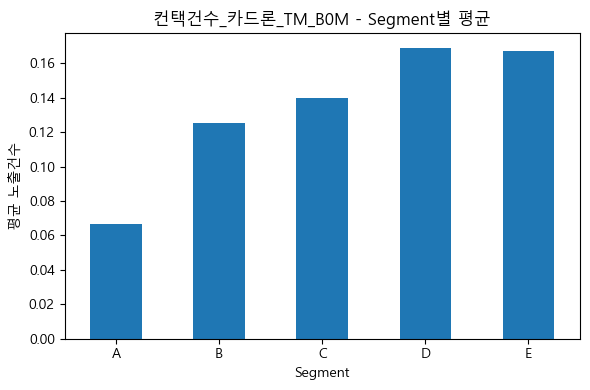

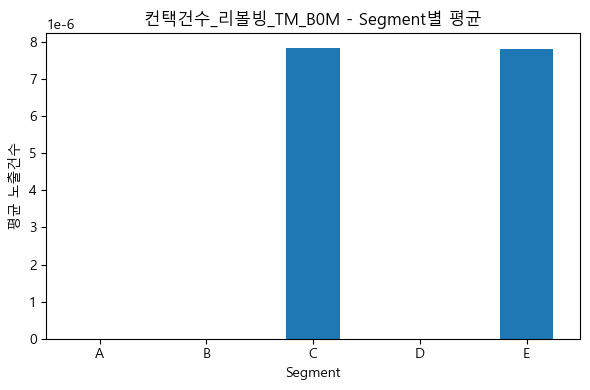

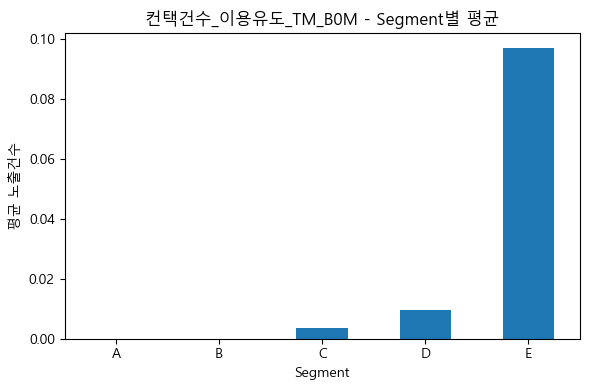

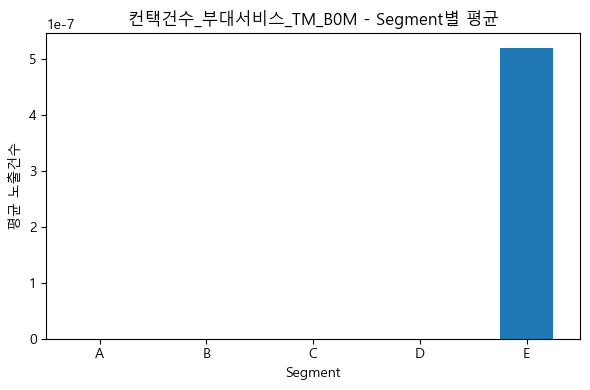

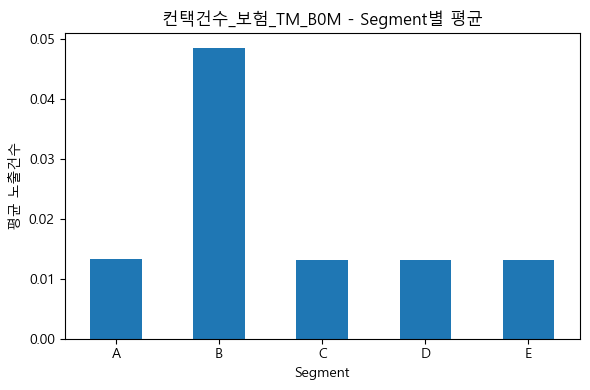

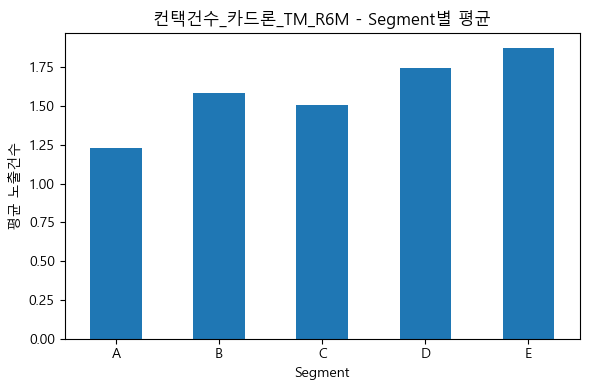

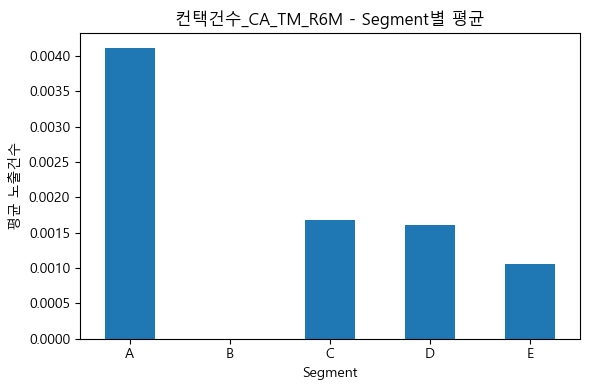

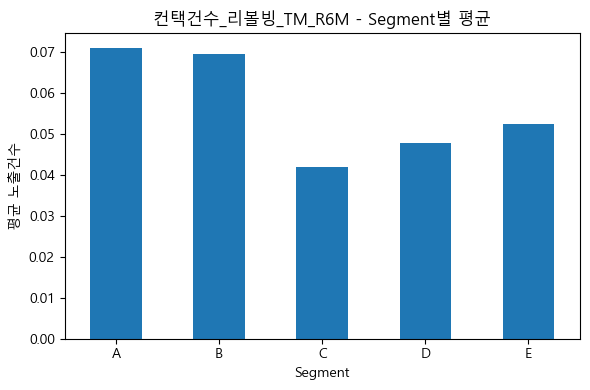

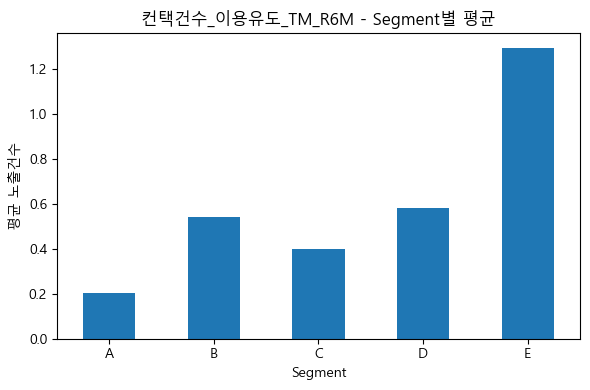

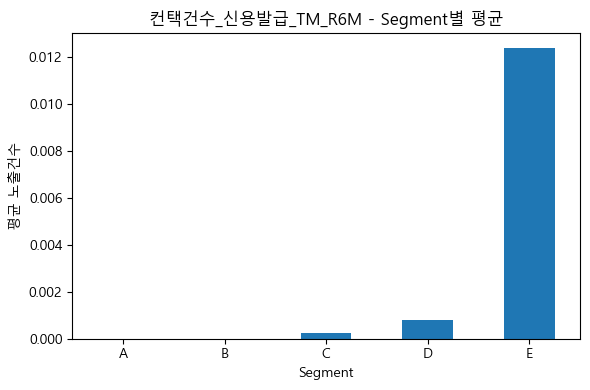

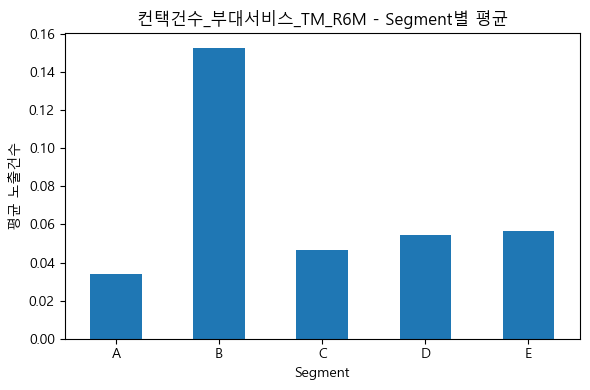

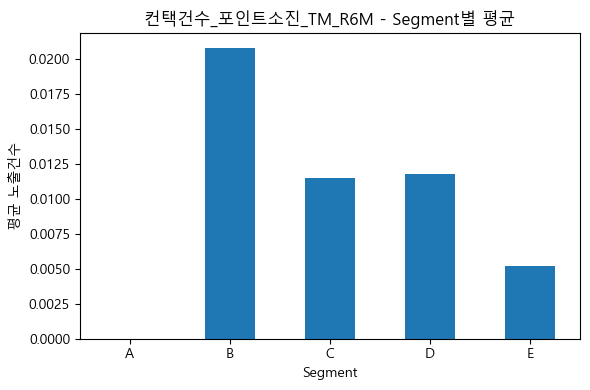

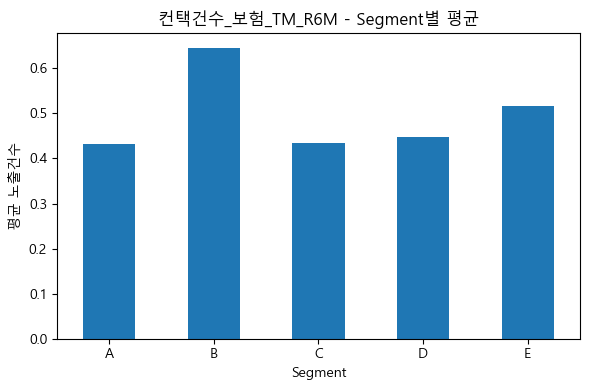

In [11]:
# TM 채널 관련 컬럼 추출
tm_cols = [col for col in merged_df.columns if '_TM_' in col]

# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[tm_cols].mean()

# 시각화
for col in tm_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 노출건수')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

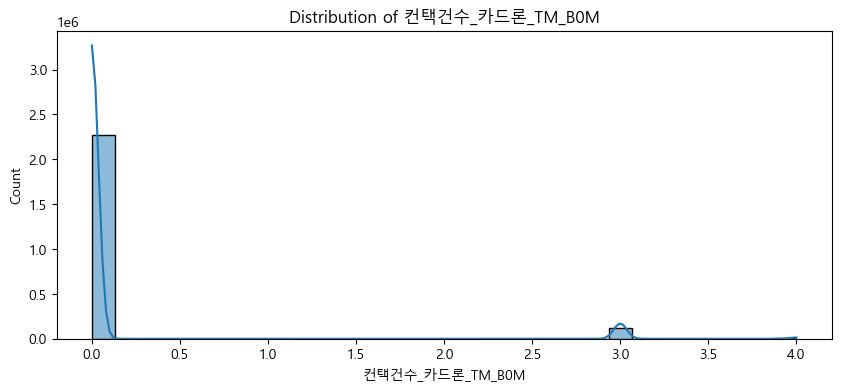

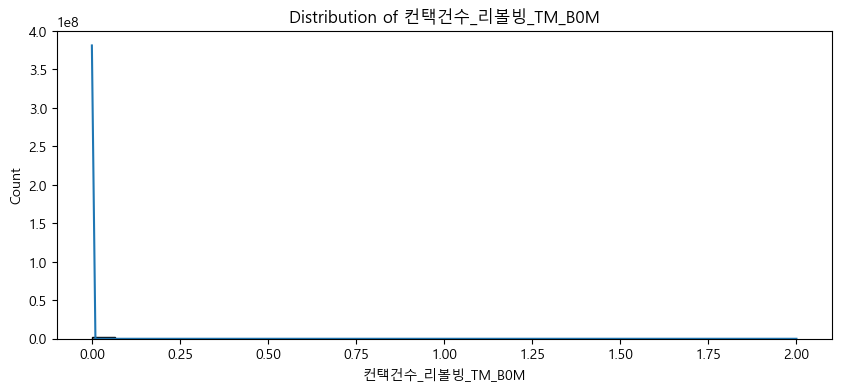

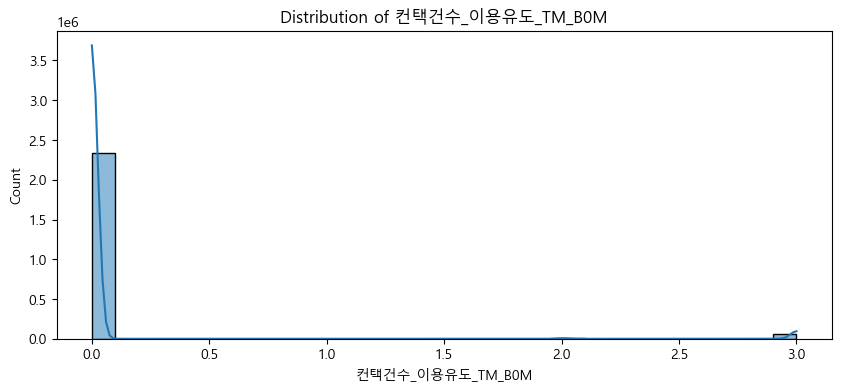

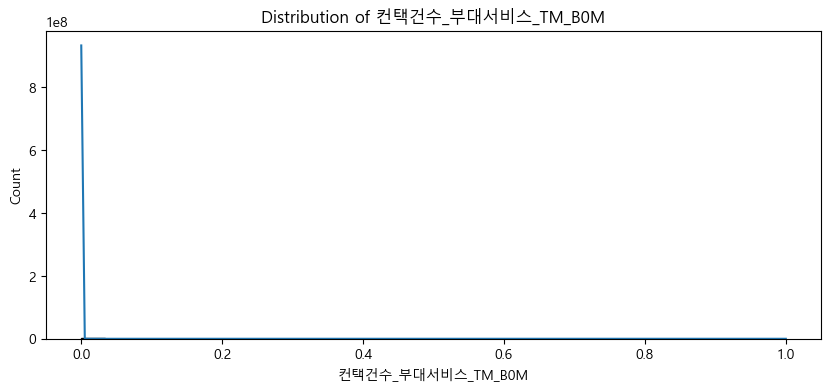

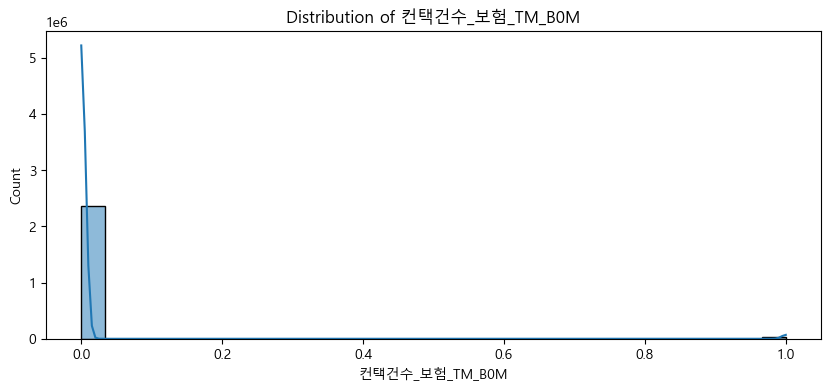

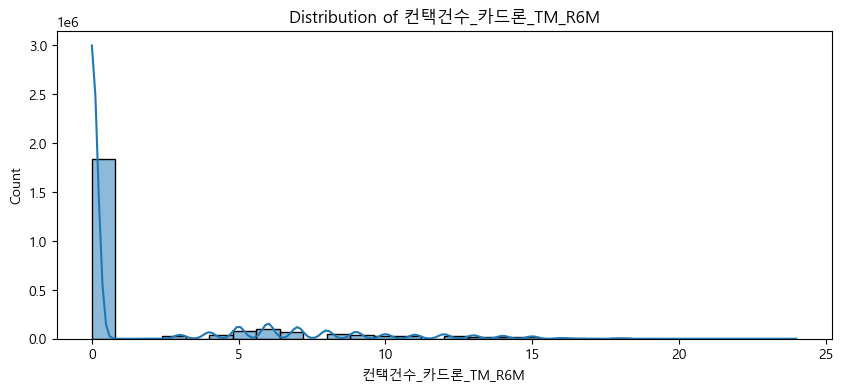

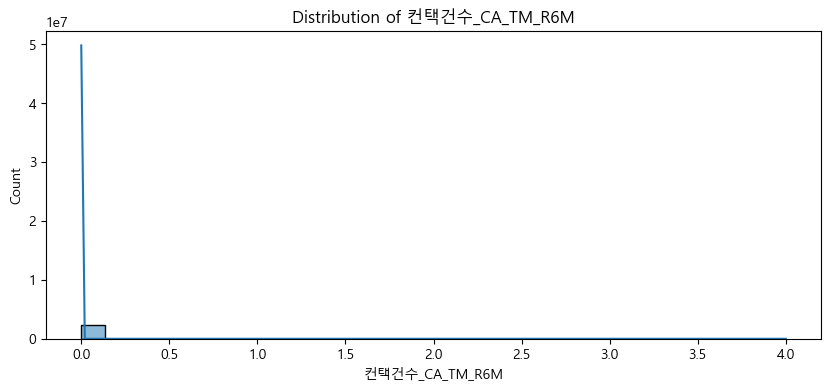

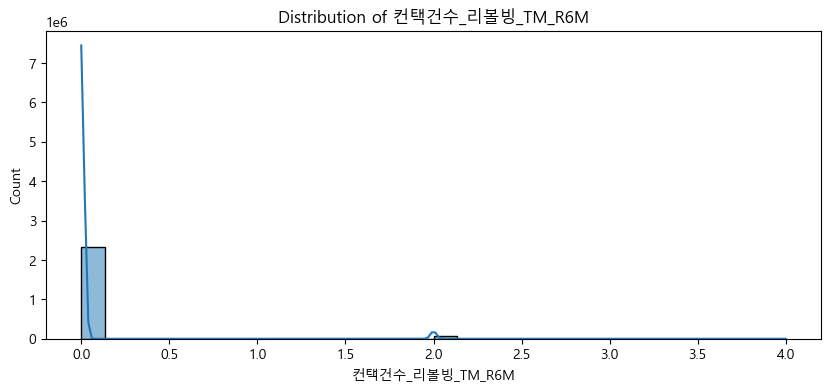

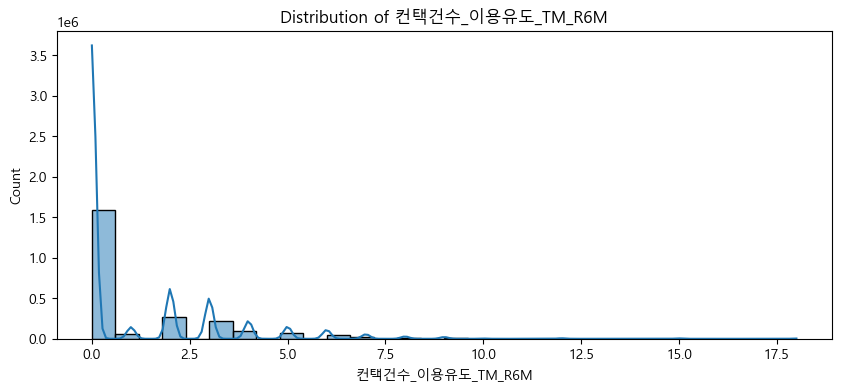

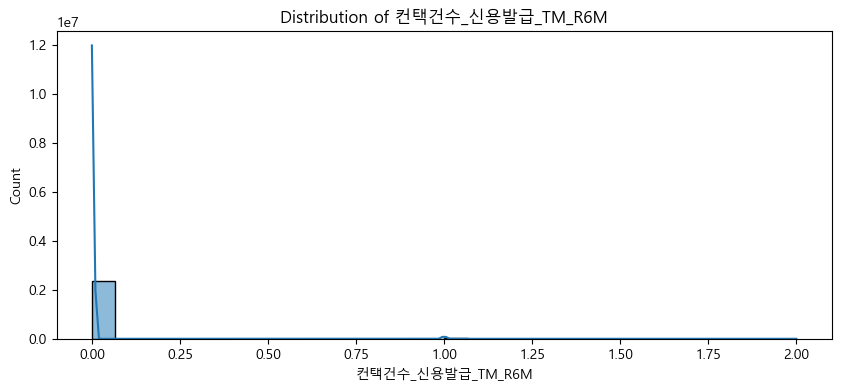

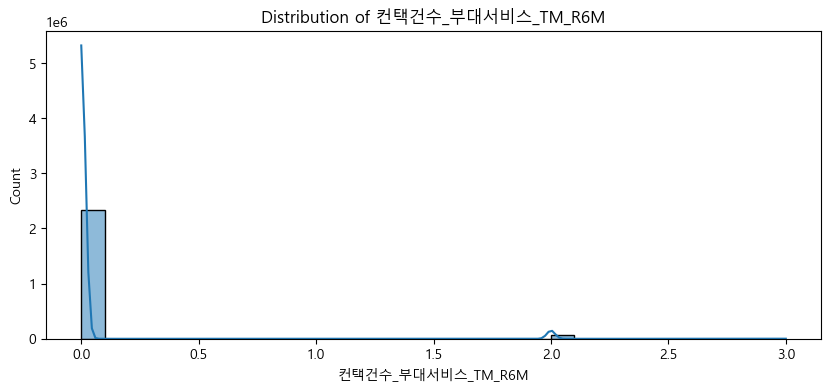

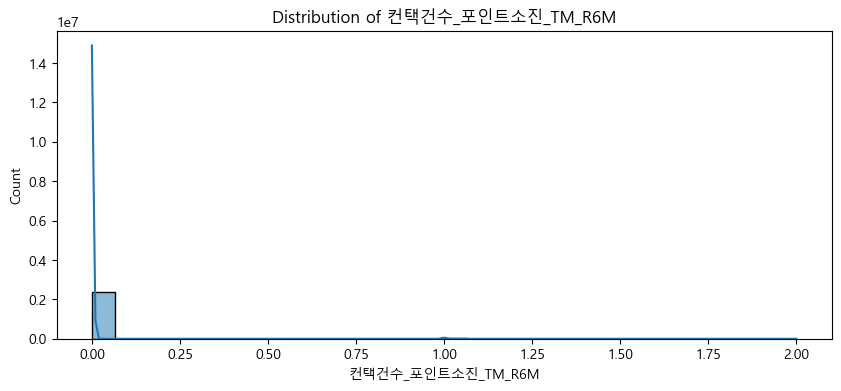

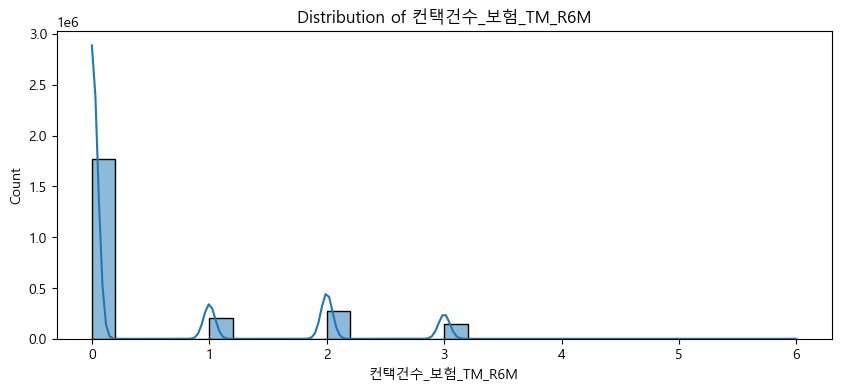

In [12]:
for col in tm_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

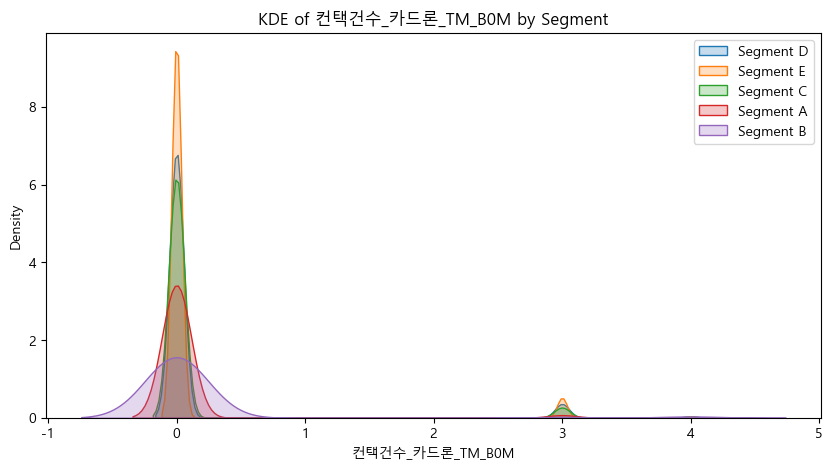

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


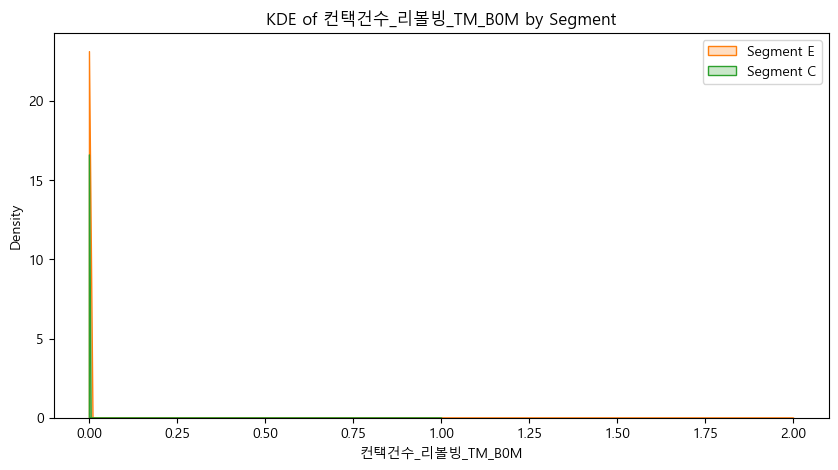

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


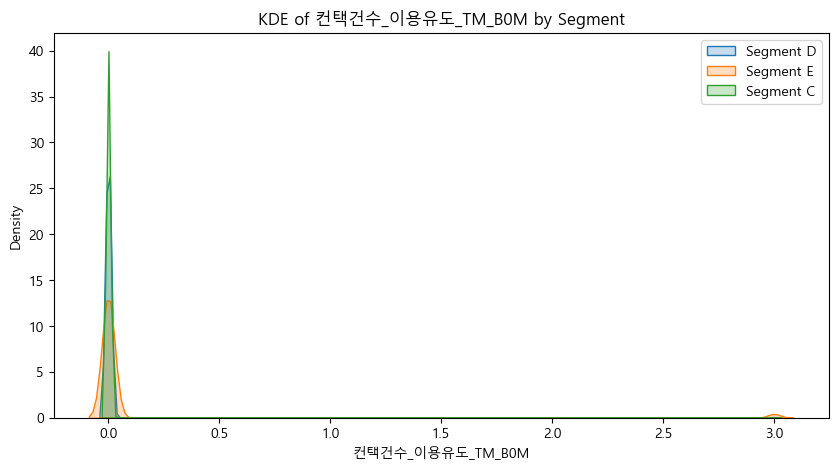

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


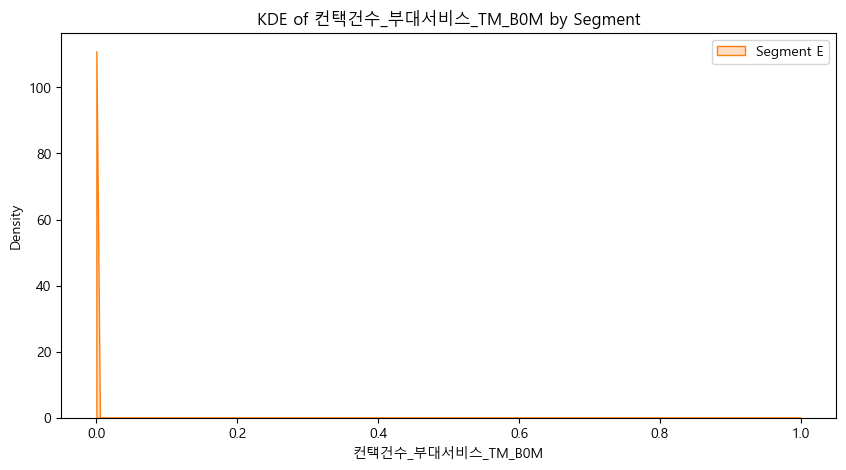

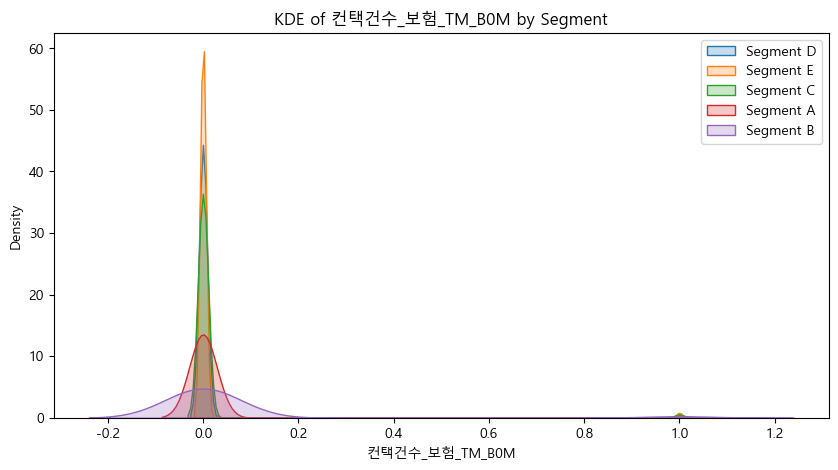

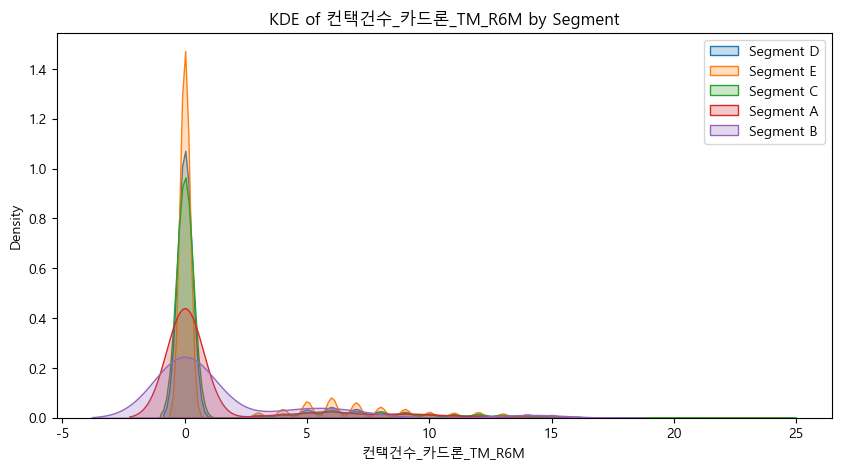

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


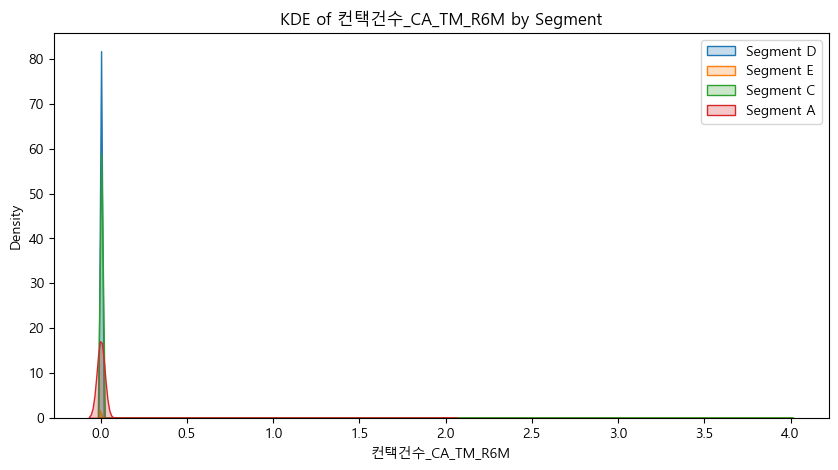

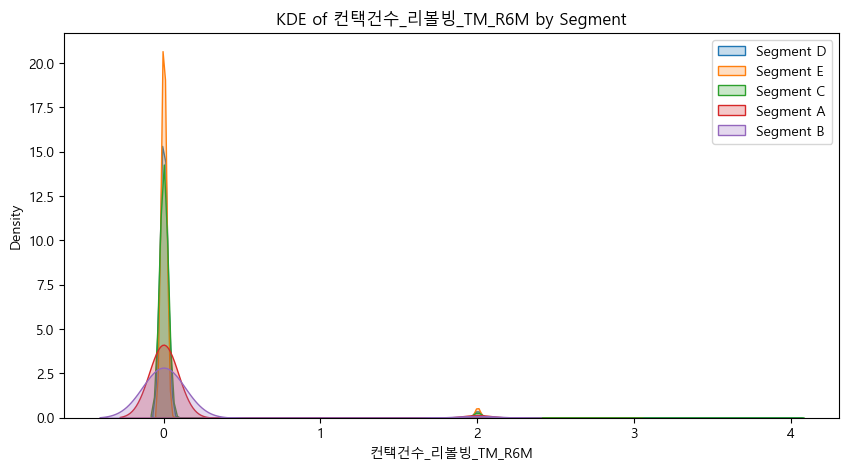

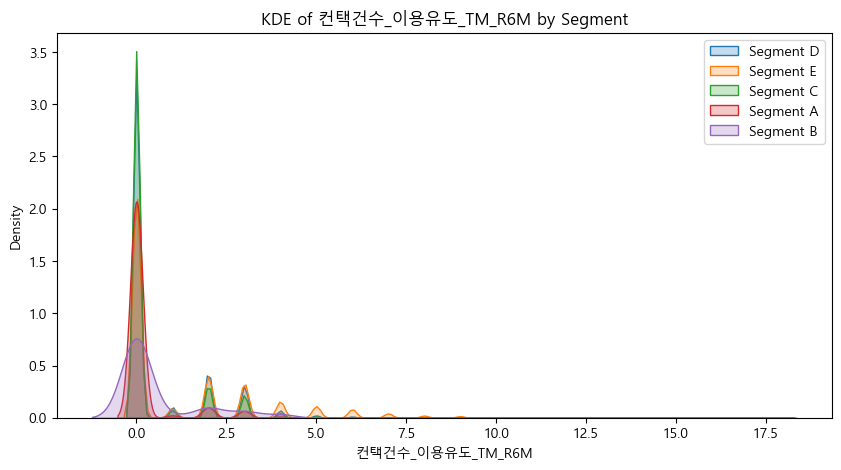

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


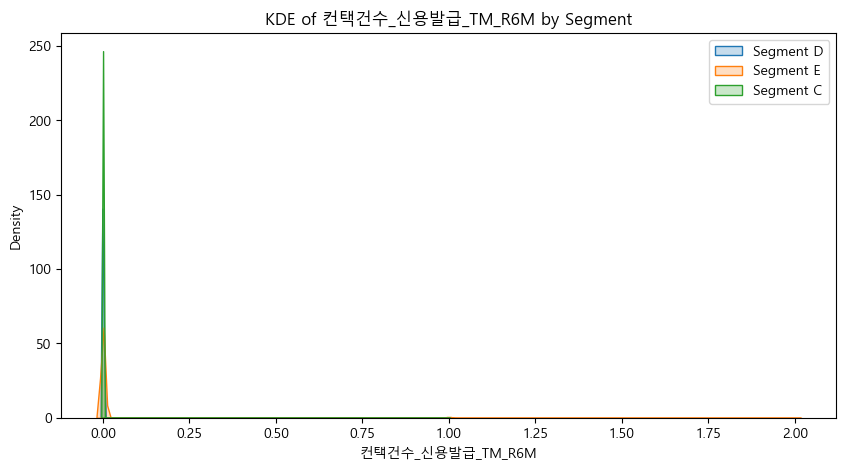

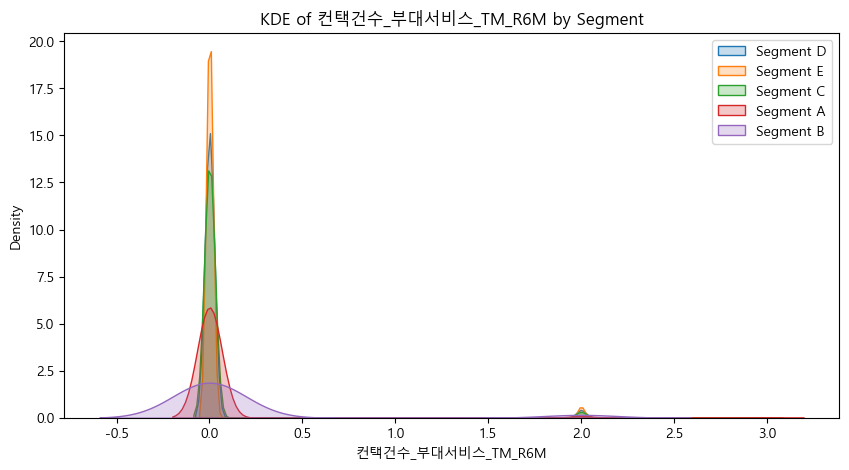

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\2542586832.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


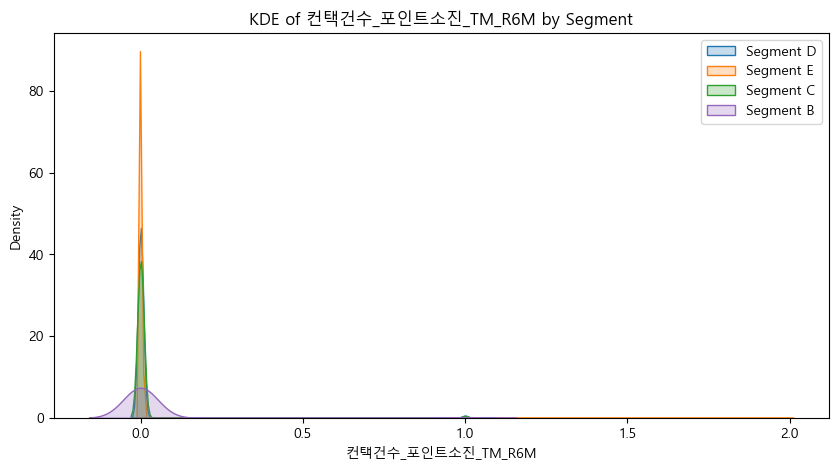

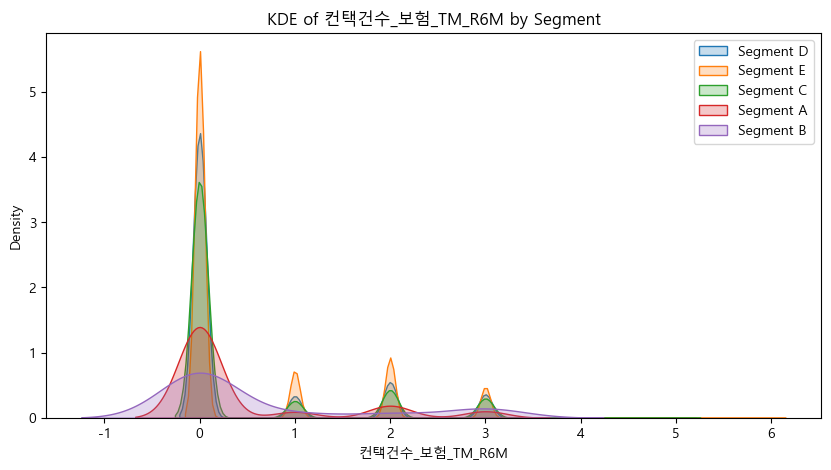

In [13]:
# tm_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in tm_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## lms_cols

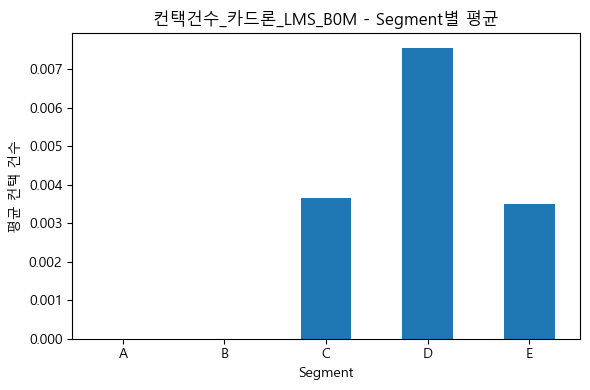

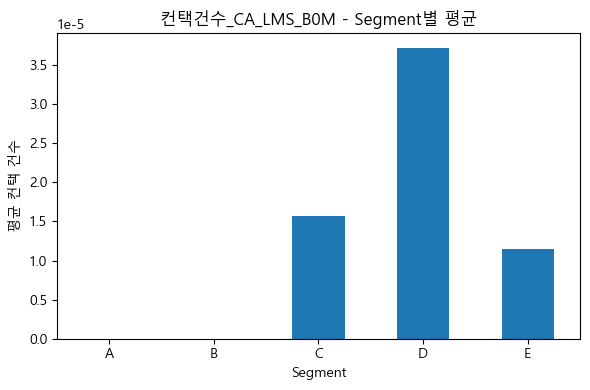

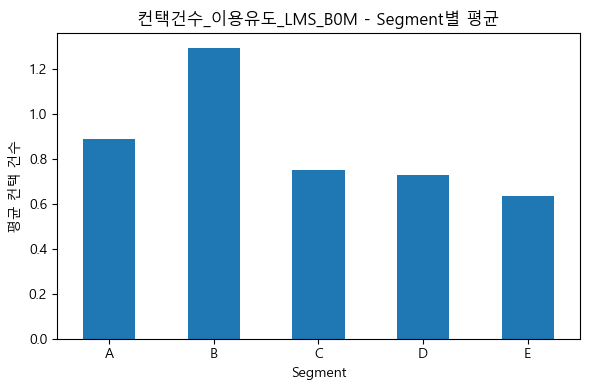

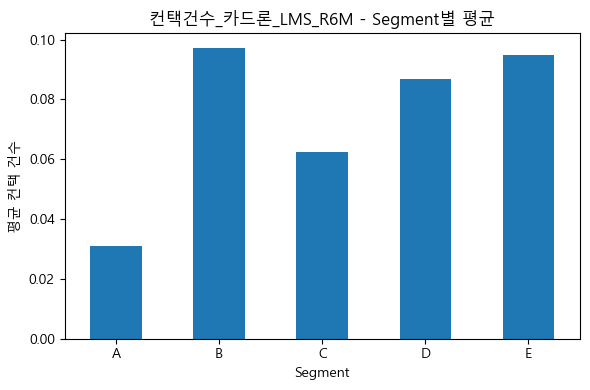

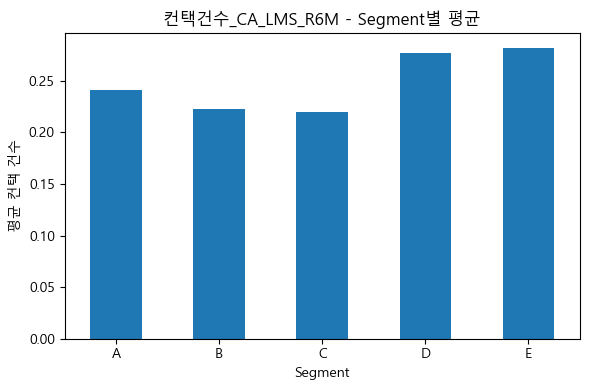

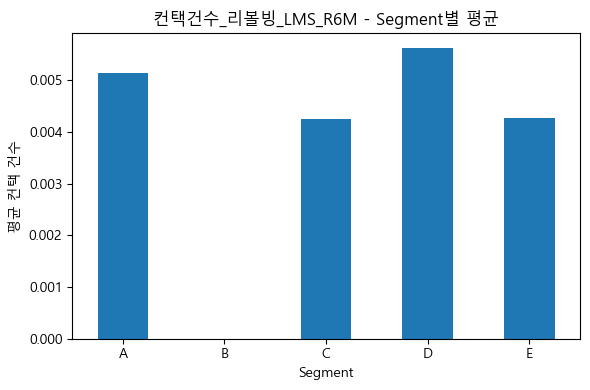

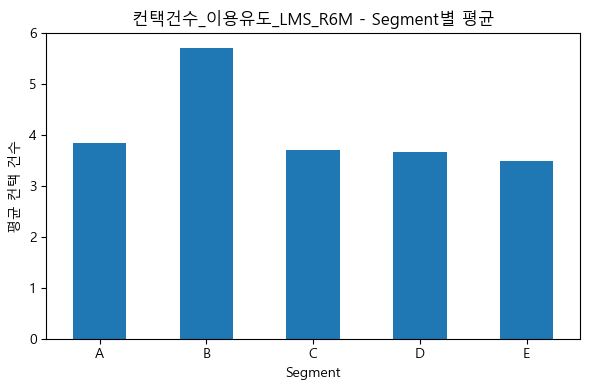

In [15]:
# LMS 채널 컬럼 추출
lms_cols = [col for col in merged_df.columns if '_LMS_' in col]

# Segment별 평균값 계산
segment_grouped = merged_df.groupby('Segment')[lms_cols].mean()

# 컬럼별로 Bar Plot 시각화
for col in lms_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 컨택 건수')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

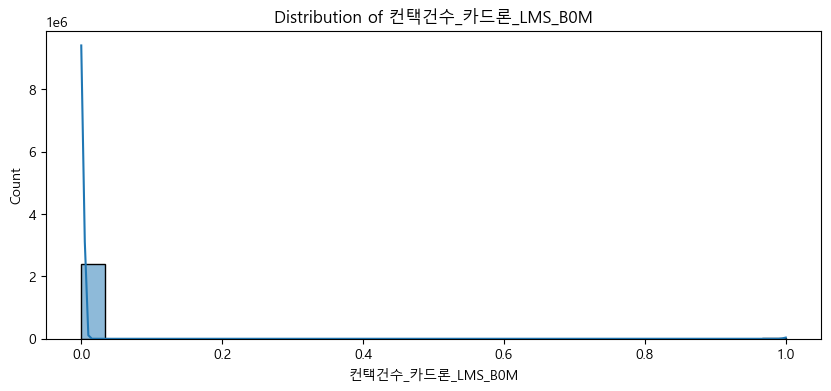

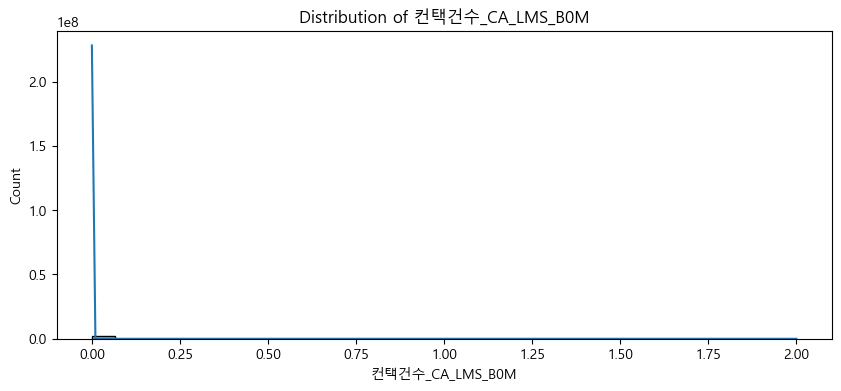

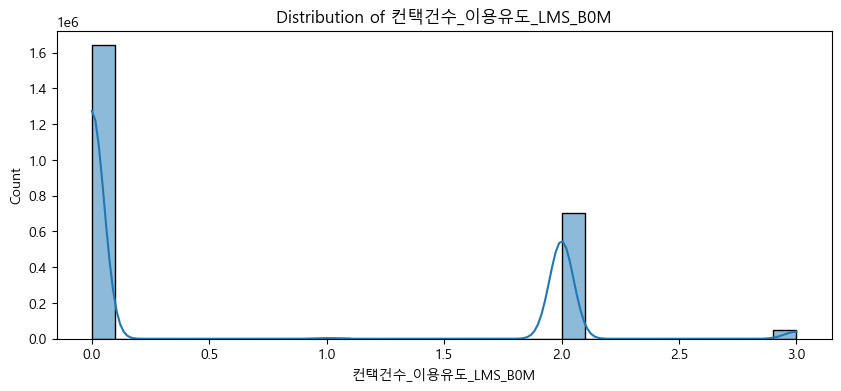

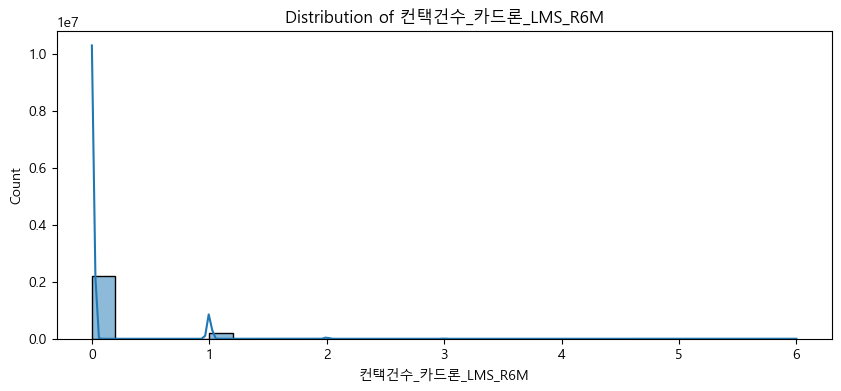

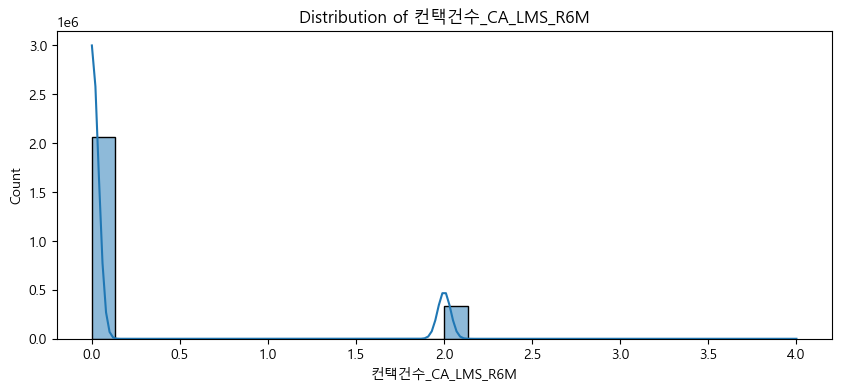

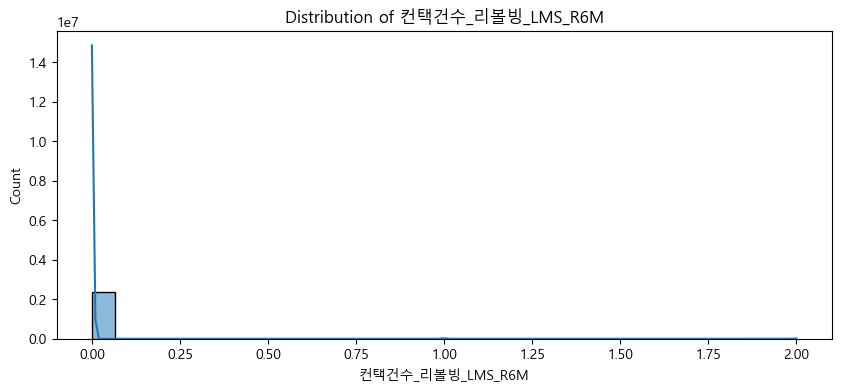

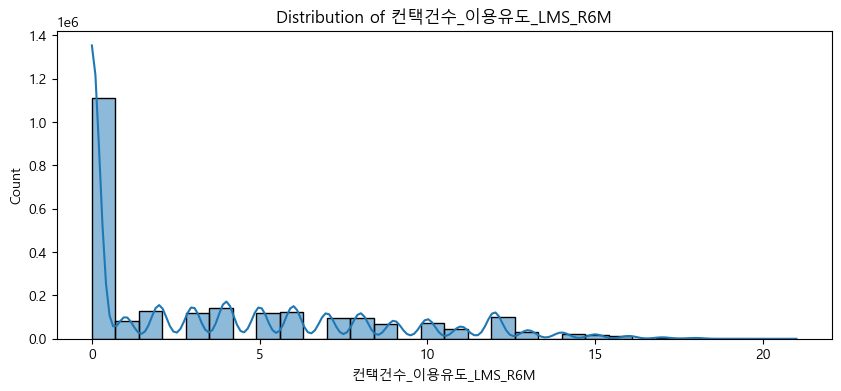

In [16]:
for col in lms_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1810968000.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1810968000.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


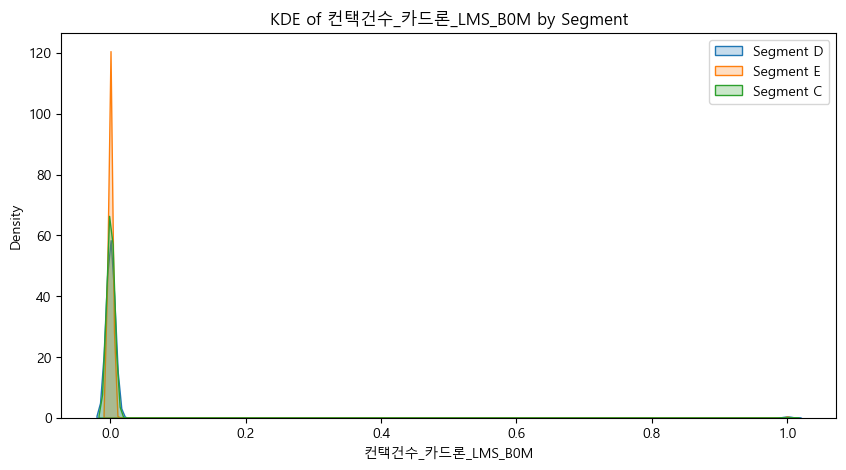

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1810968000.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1810968000.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


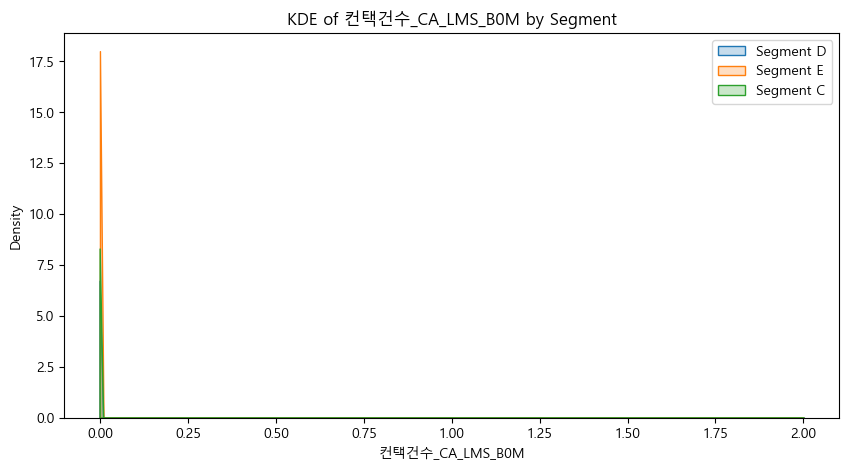

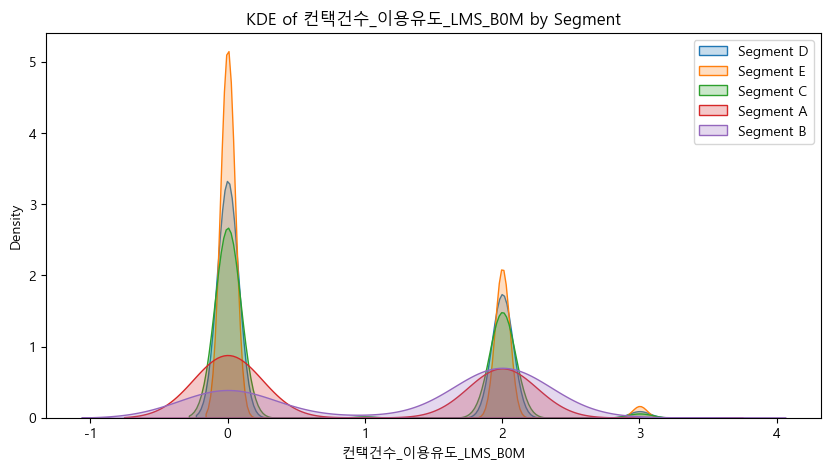

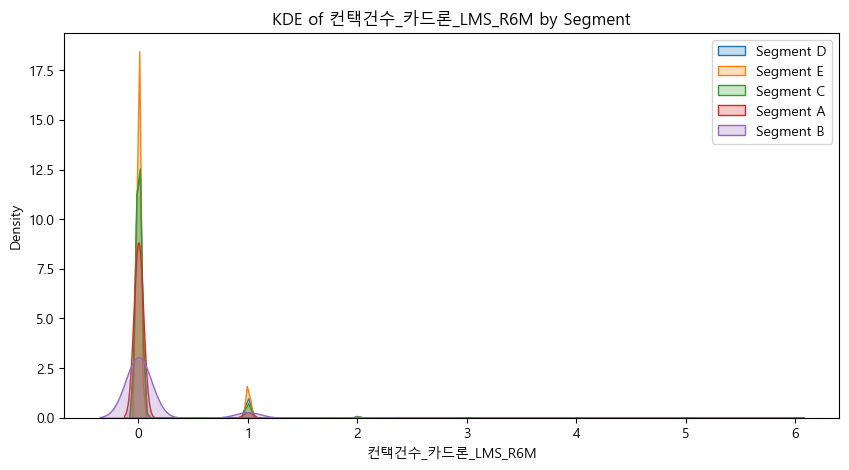

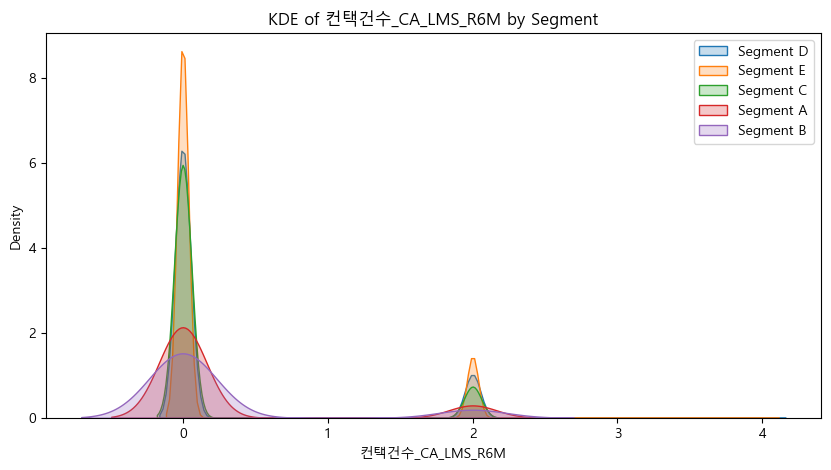

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1810968000.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


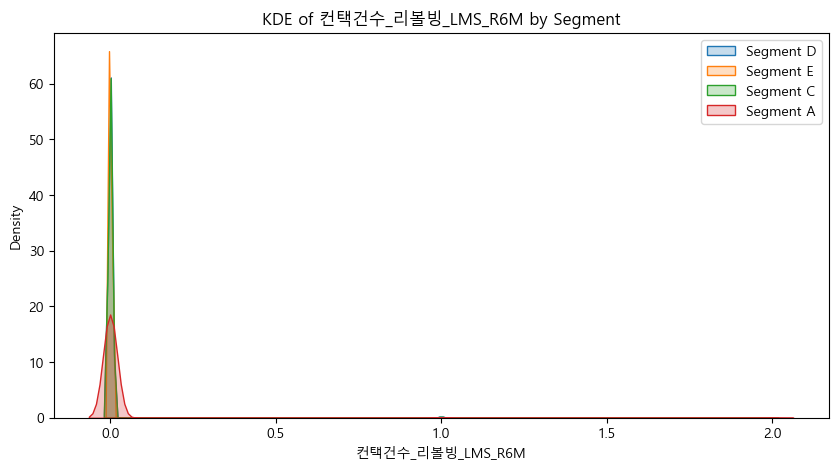

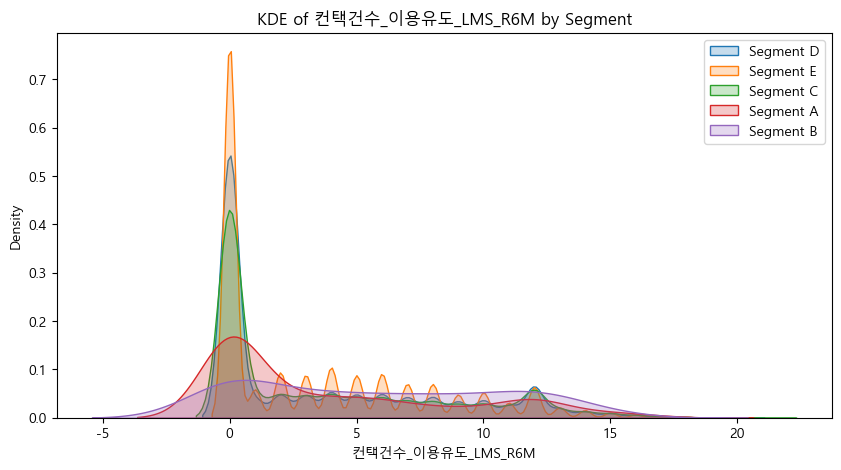

In [17]:
# lms_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in lms_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## em_cols

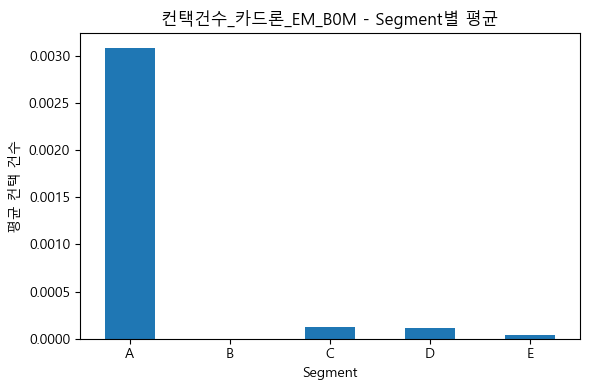

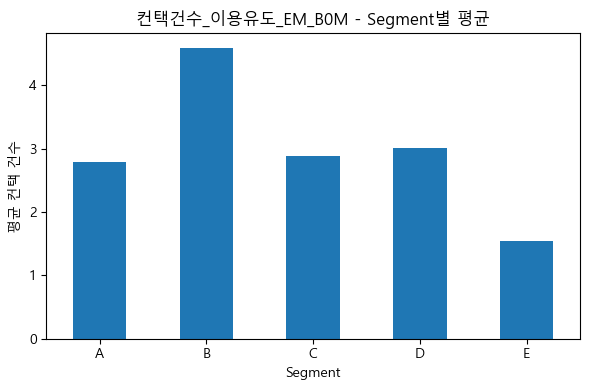

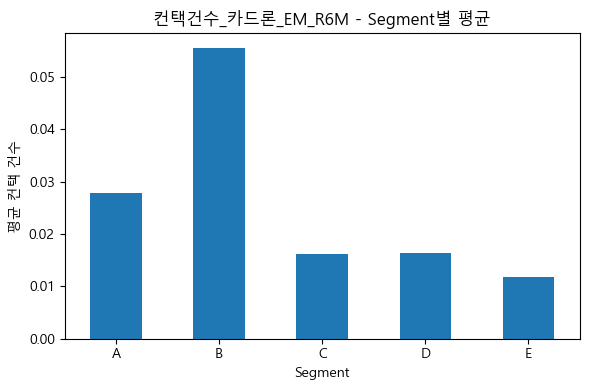

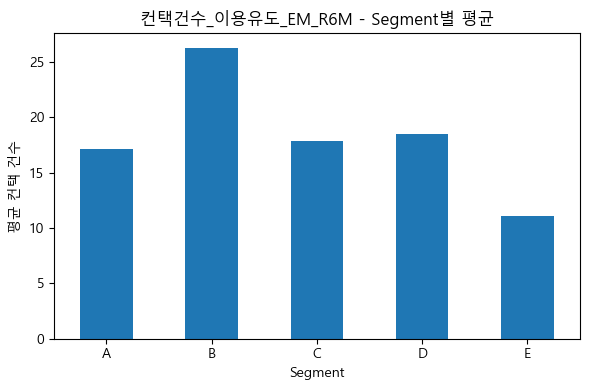

In [19]:
# 이메일 채널 컬럼 추출
em_cols = [col for col in merged_df.columns if '_EM_' in col]

# Segment별 평균값 계산
segment_grouped = merged_df.groupby('Segment')[em_cols].mean()

# 컬럼별로 Bar Plot 시각화
for col in em_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 컨택 건수')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

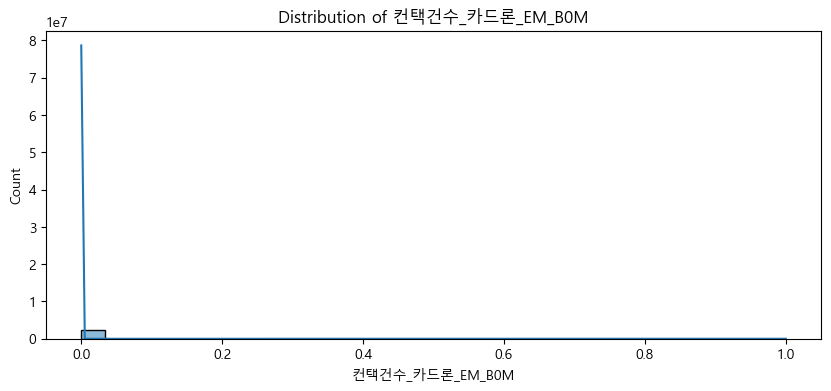

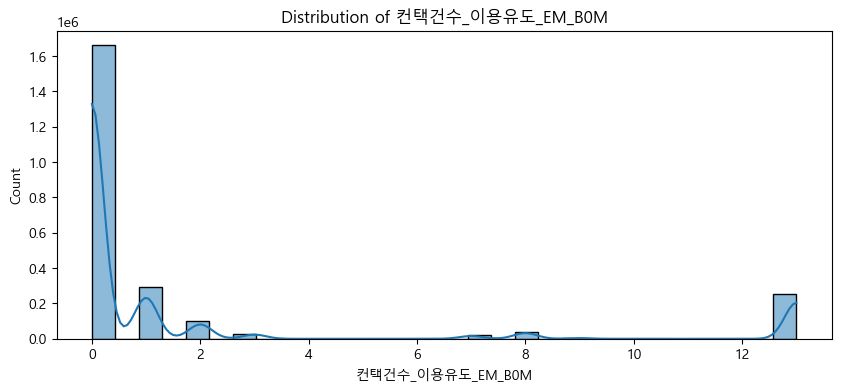

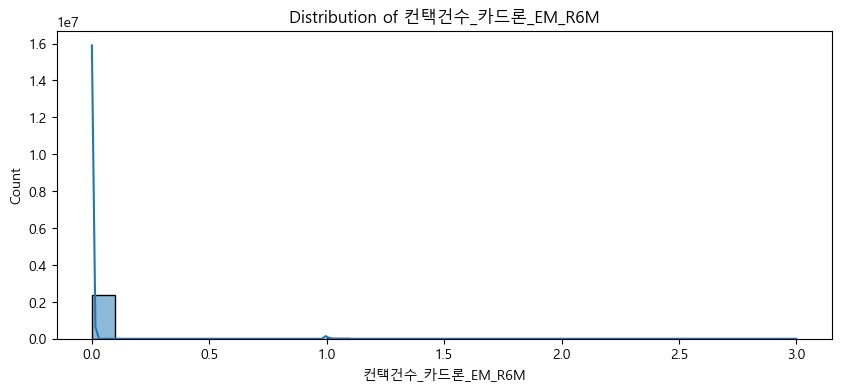

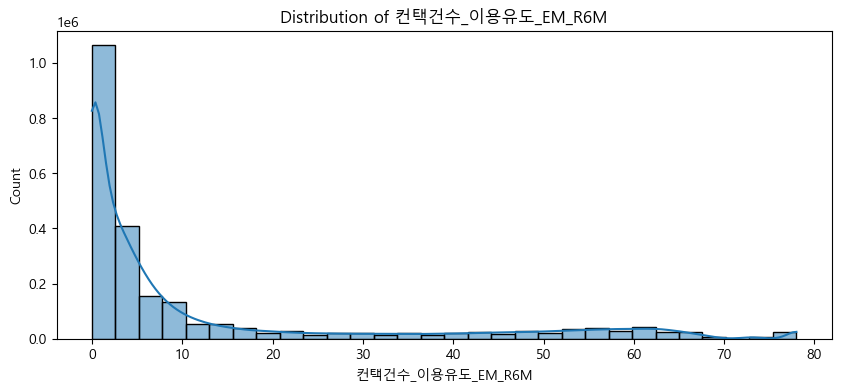

In [20]:
for col in em_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\4027663069.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


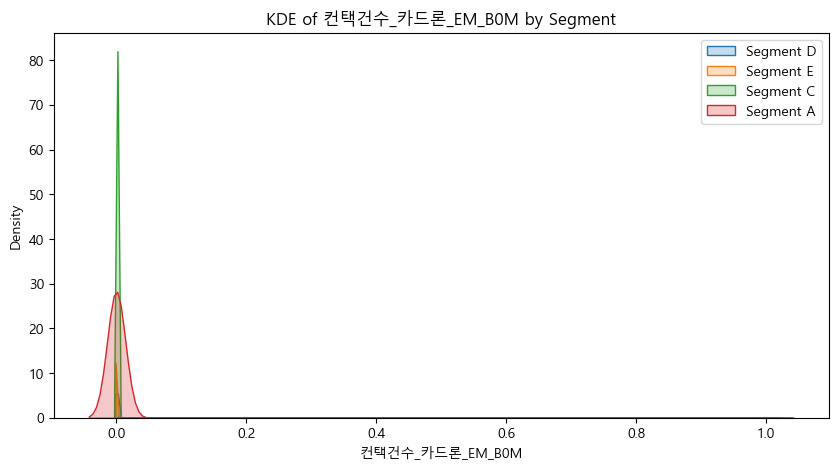

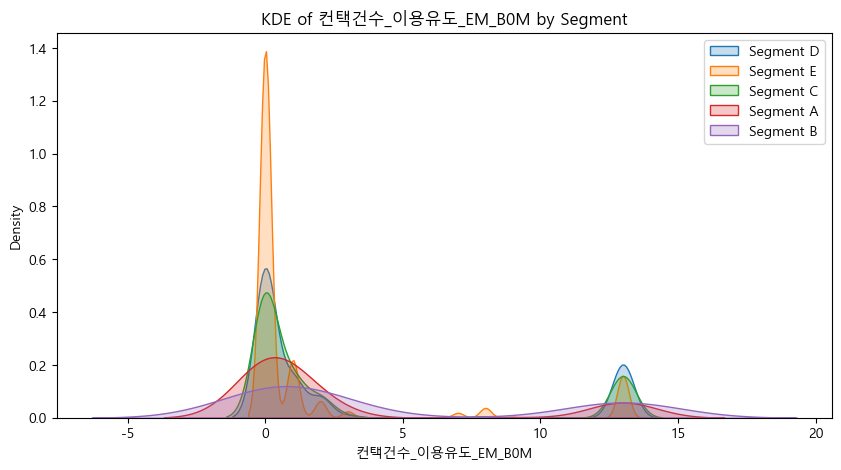

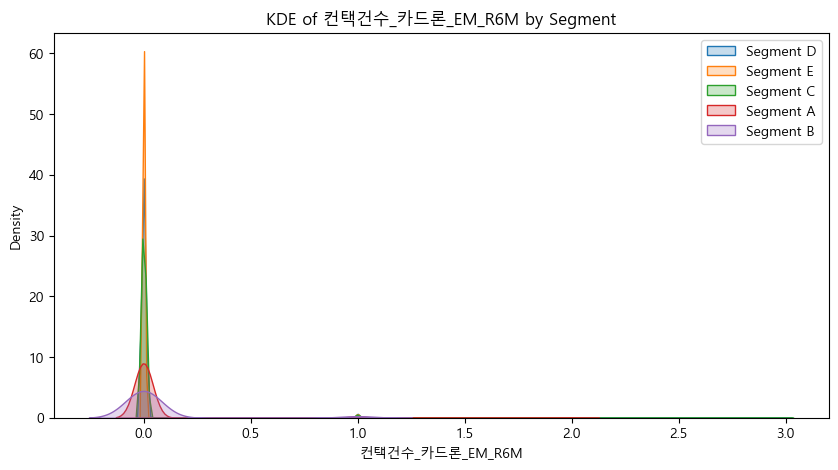

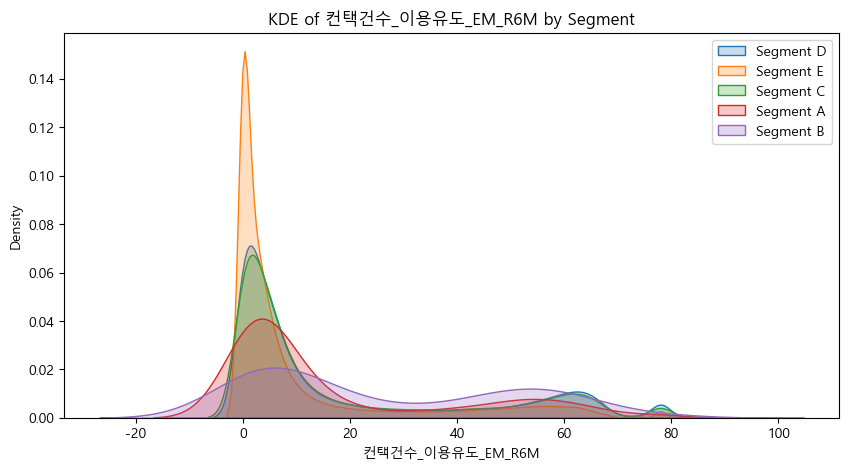

In [21]:
# em_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in em_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## bill_cols

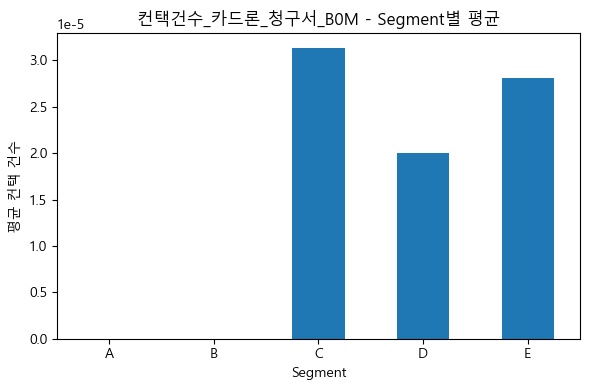

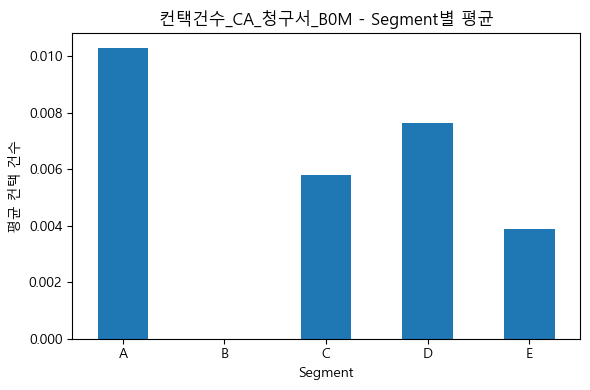

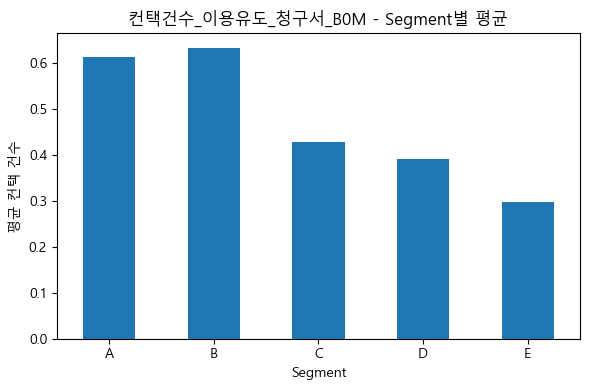

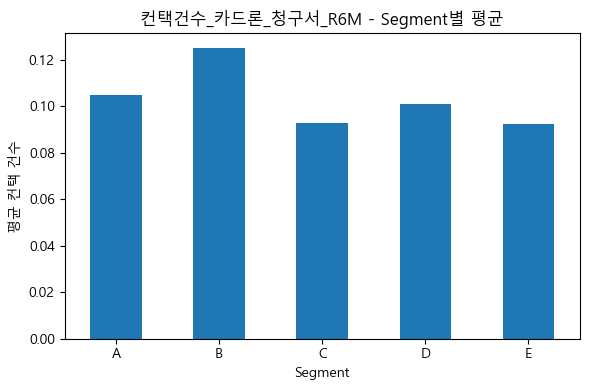

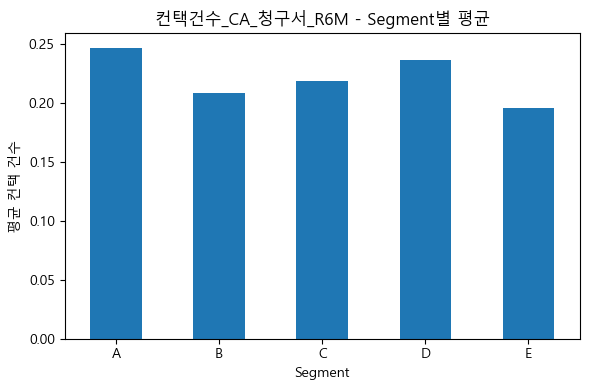

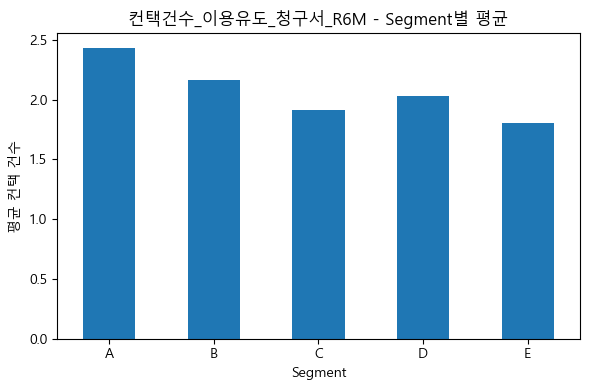

In [23]:
# 청구서 채널 관련 컬럼 추출
bill_cols = [col for col in merged_df.columns if '_청구서_' in col]

# Segment별 평균값 계산
segment_grouped = merged_df.groupby('Segment')[bill_cols].mean()

# 컬럼별 막대그래프 시각화
for col in bill_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 컨택 건수')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

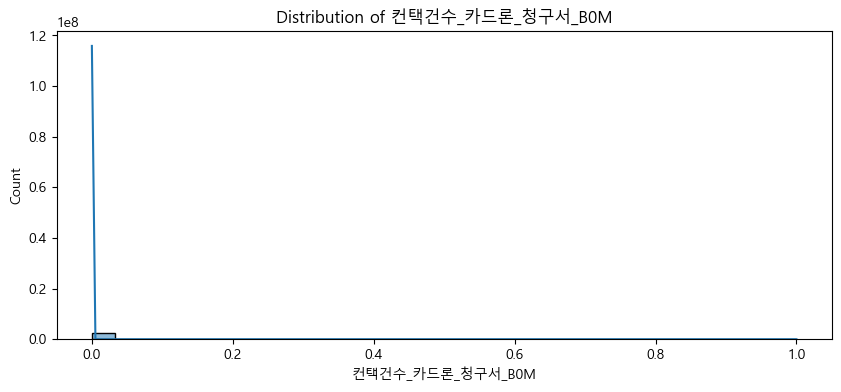

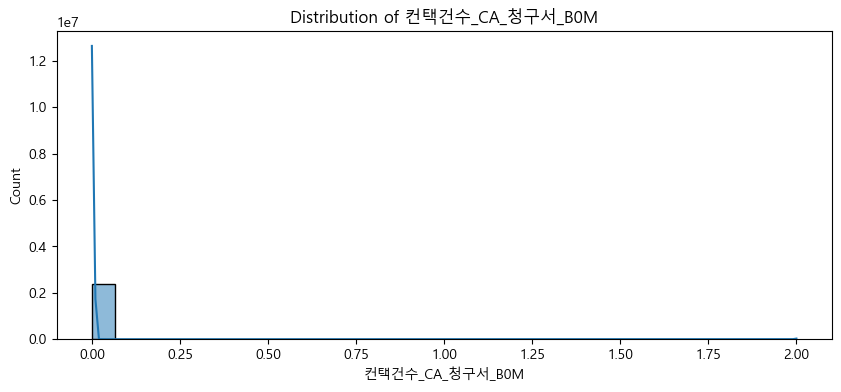

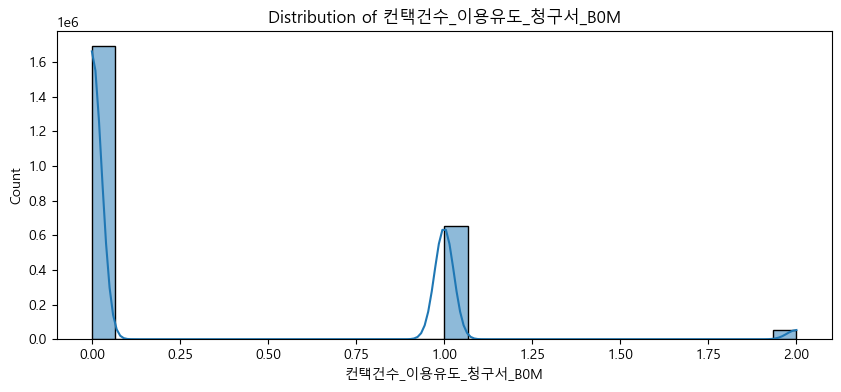

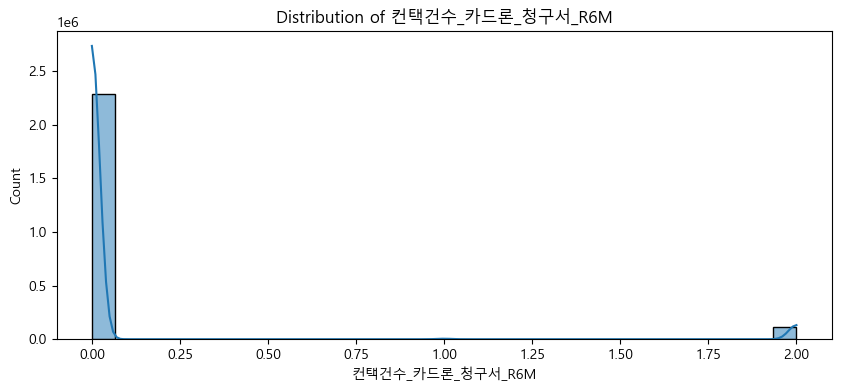

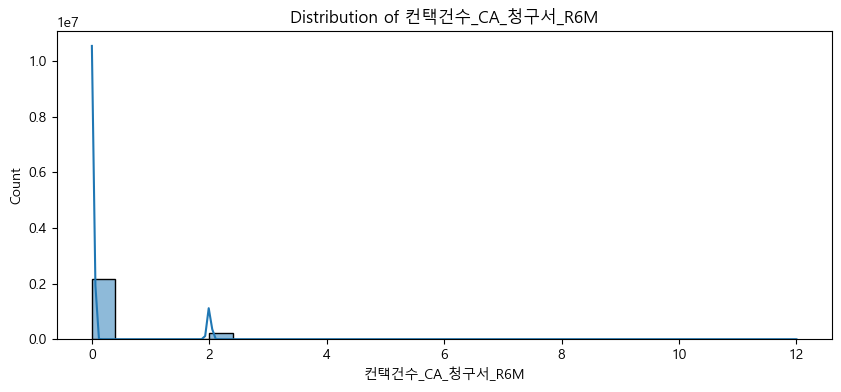

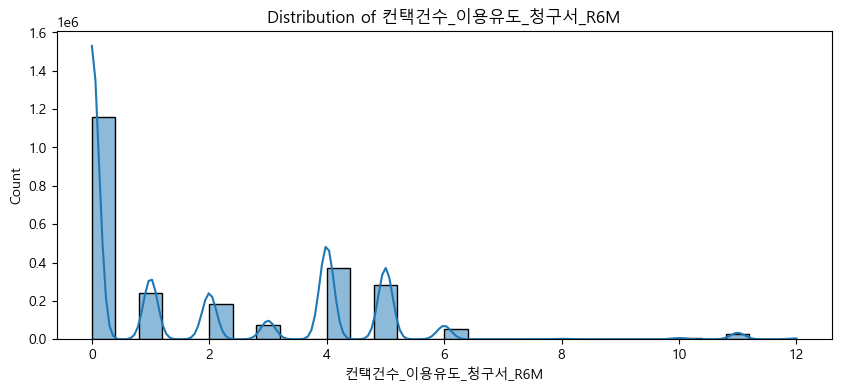

In [24]:
for col in bill_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1064123655.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1064123655.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


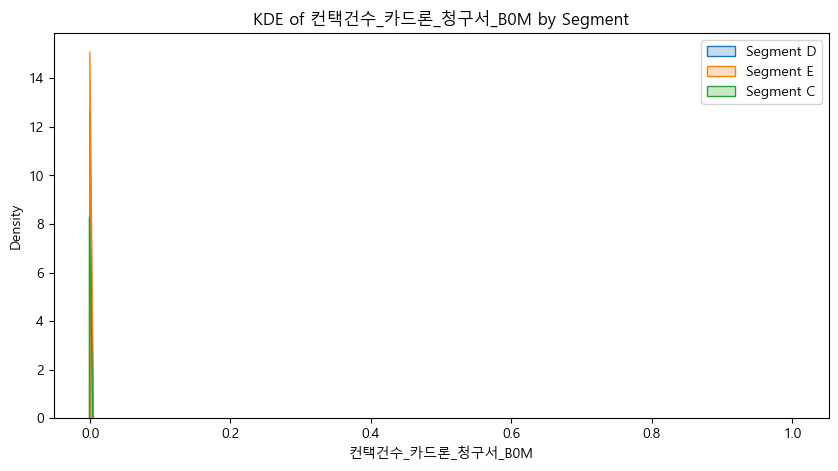

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\1064123655.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


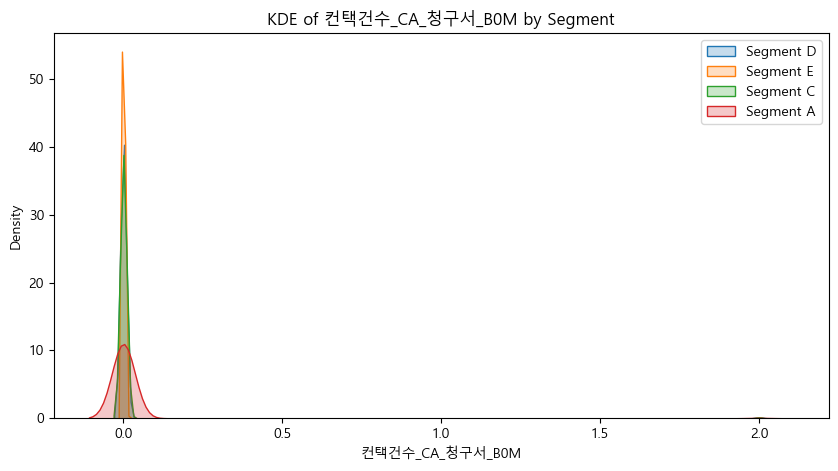

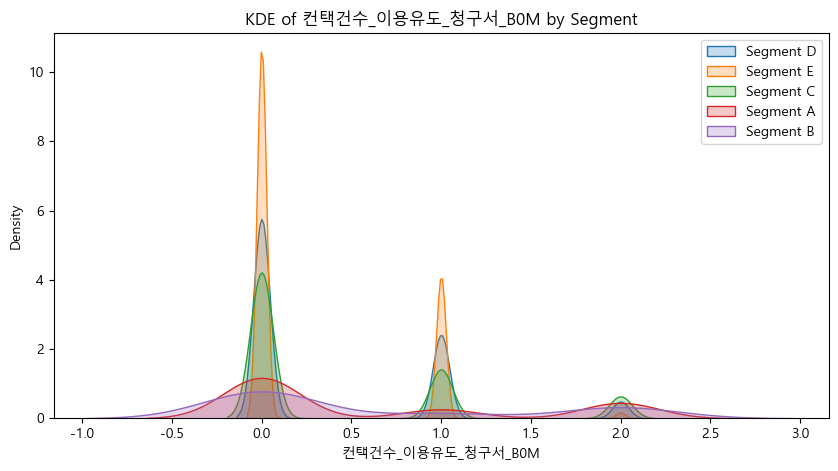

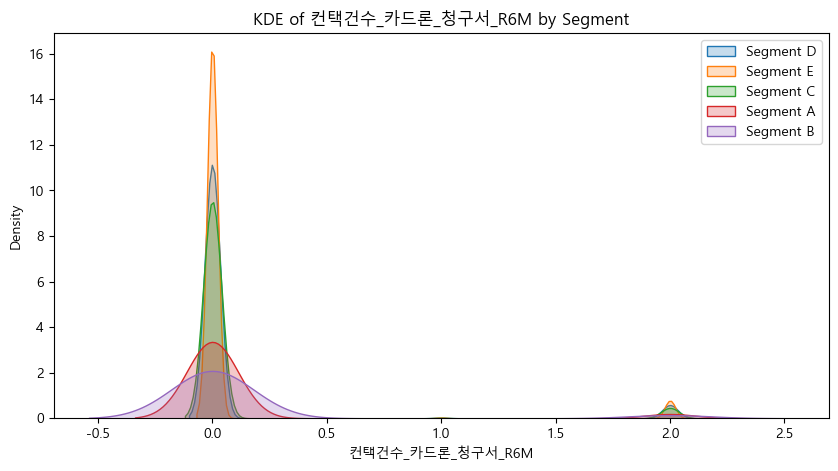

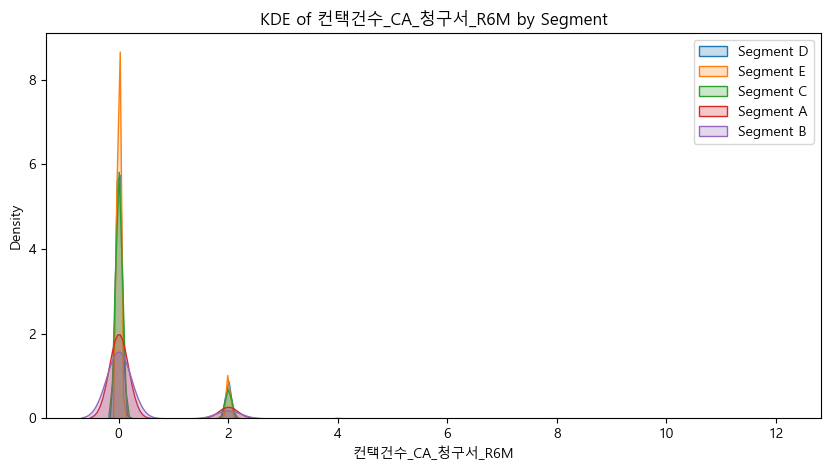

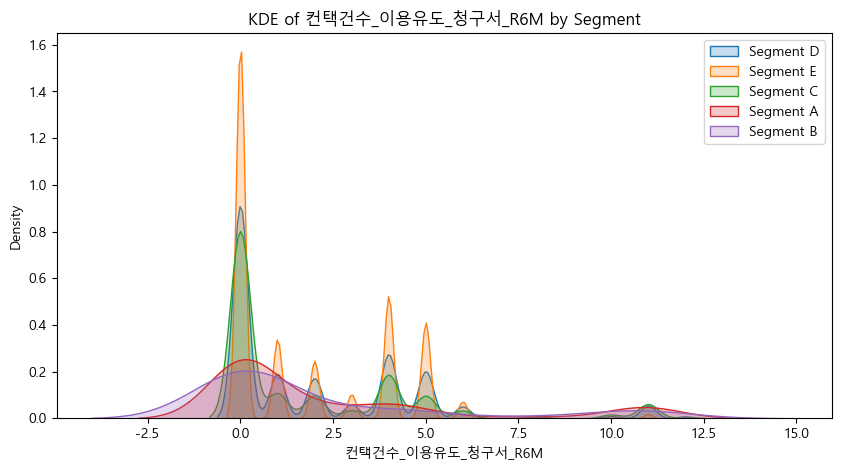

In [25]:
# bill_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in bill_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## web_cols

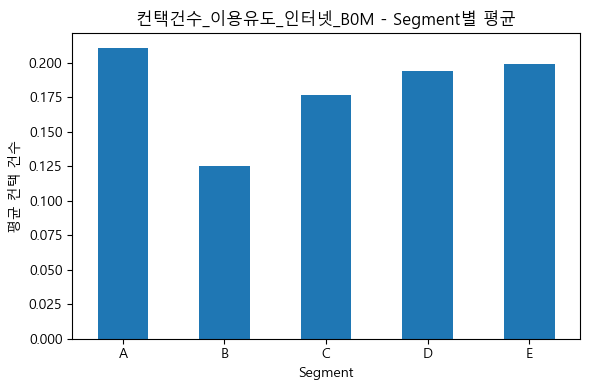

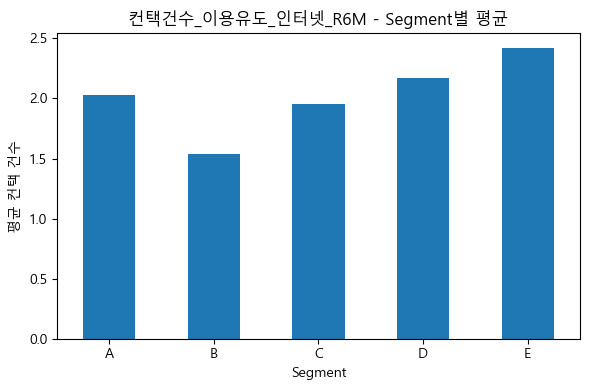

In [27]:
# 인터넷 채널 관련 컬럼 추출
web_cols = [col for col in merged_df.columns if '_인터넷_' in col]

# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[web_cols].mean()

# 컬럼별로 막대그래프 시각화
for col in web_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 컨택 건수')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


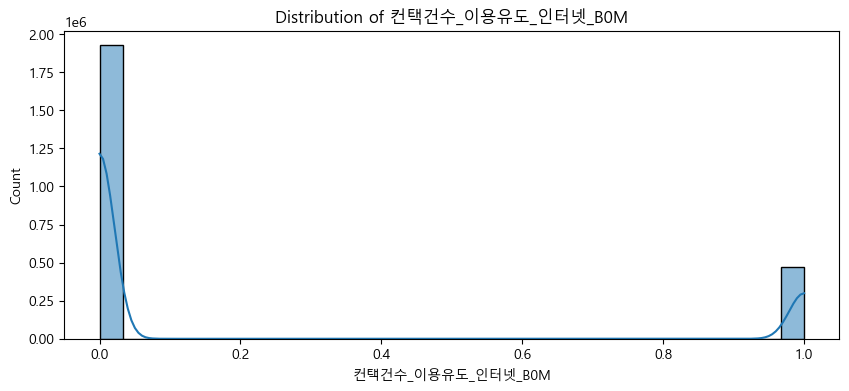

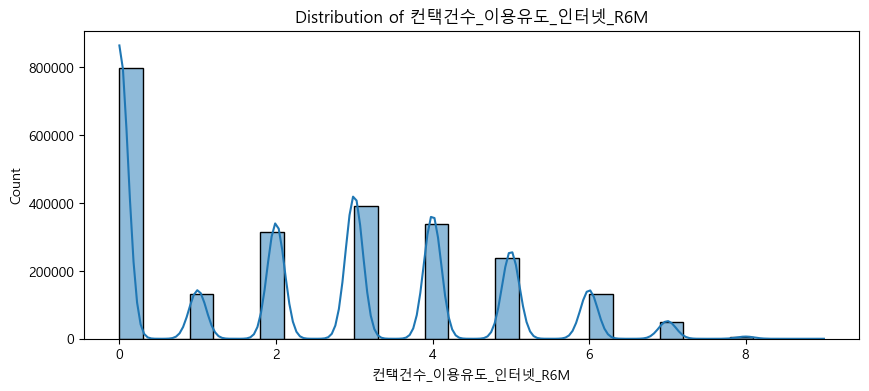

In [28]:
for col in web_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

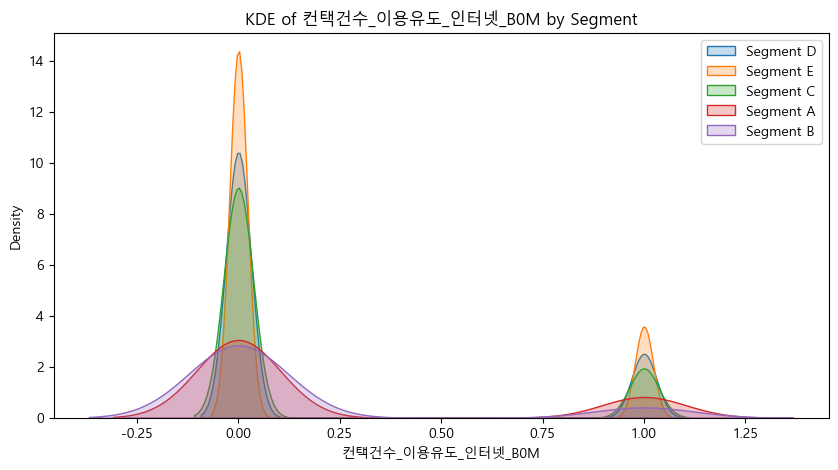

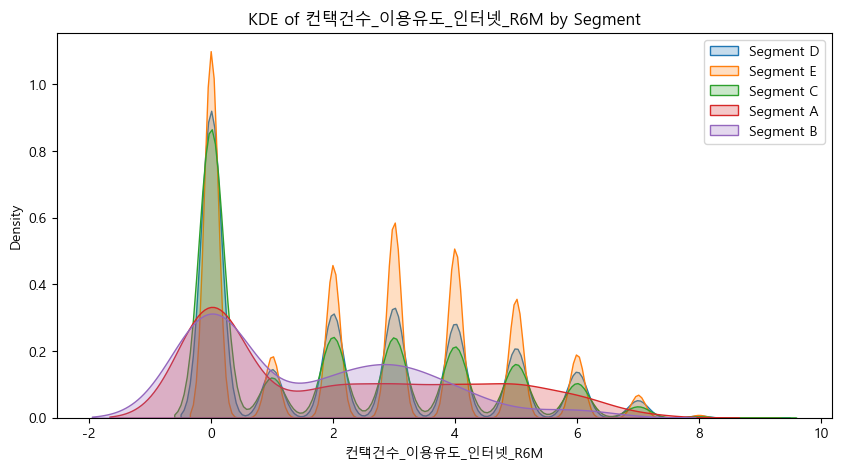

In [29]:
# web_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in web_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## app_cols

In [31]:
# 당사앱 채널 관련 컬럼 추출
app_cols = [col for col in merged_df.columns if '_당사앱_' in col]

# Segment별 평균값 계산
segment_grouped = merged_df.groupby('Segment')[app_cols].mean()

# 컬럼별 Bar Plot 시각화
for col in app_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 컨택 건수')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [32]:
for col in app_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

In [33]:
# app_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in app_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## risk_cols

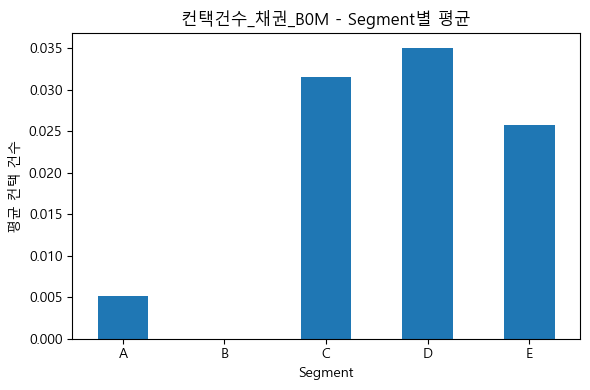

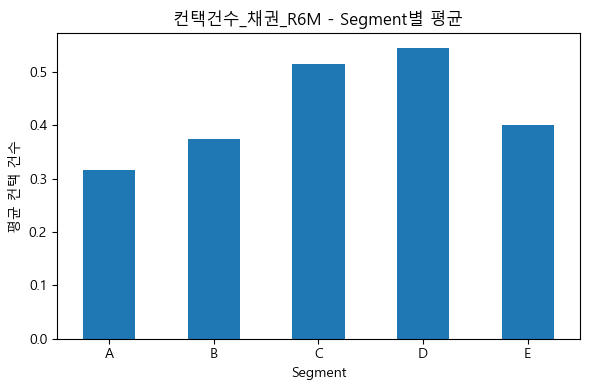

In [35]:
# 채권 & FDS 관련 컬럼 추출
risk_cols = [col for col in merged_df.columns if '채권' in col or 'FDS' in col]

# Segment별 평균값 계산
segment_grouped = merged_df.groupby('Segment')[risk_cols].mean()

# 컬럼별 Bar Plot 시각화
for col in risk_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 컨택 건수')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

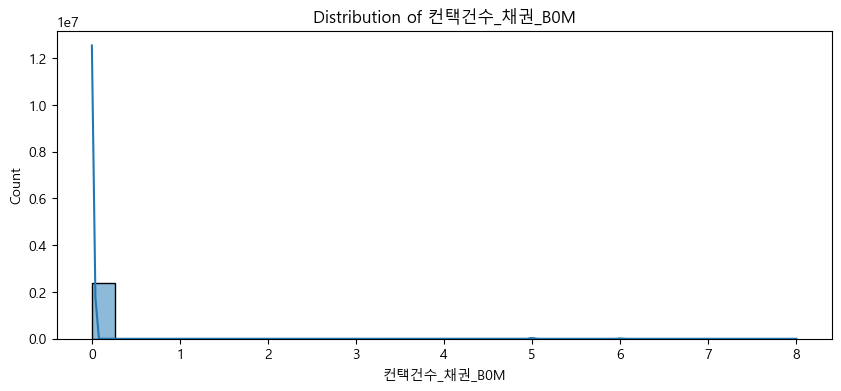

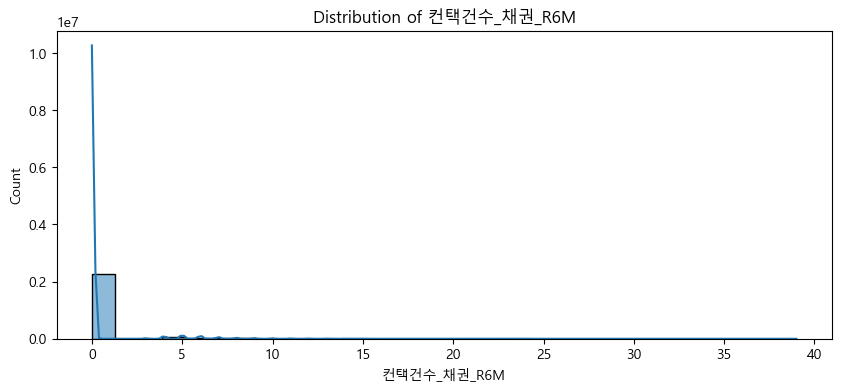

In [36]:
for col in risk_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

C:\Users\xodlf\AppData\Local\Temp\ipykernel_11600\3525030893.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


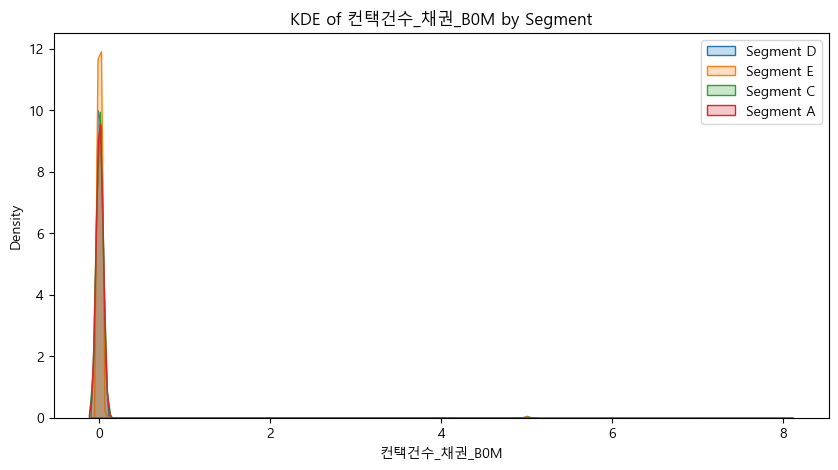

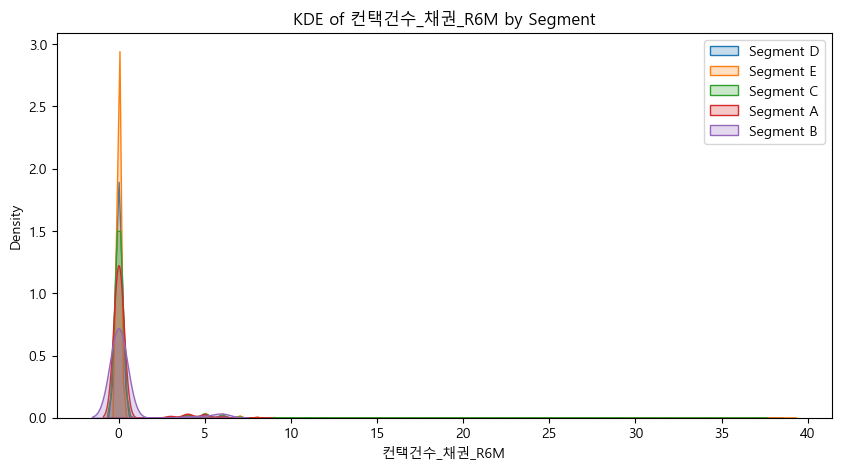

In [37]:
# risk_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in risk_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## campaign_cols

In [39]:
# 캠페인 컬럼 정의
campaign_cols = [col for col in merged_df.columns if col.startswith('캠페인접촉')]

# 문자열에서 숫자 추출 함수
def extract_numeric(text):
    if pd.isna(text):
        return None
    match = re.search(r'\d+', str(text))
    return int(match.group()) if match else None

# 캠페인 관련 컬럼을 숫자로 변환
for col in campaign_cols:
    merged_df[col] = merged_df[col].apply(extract_numeric)

# 변환 확인
print(merged_df[campaign_cols].dtypes)

캠페인접촉건수_R12M    int64
캠페인접촉일수_R12M    int64
dtype: object


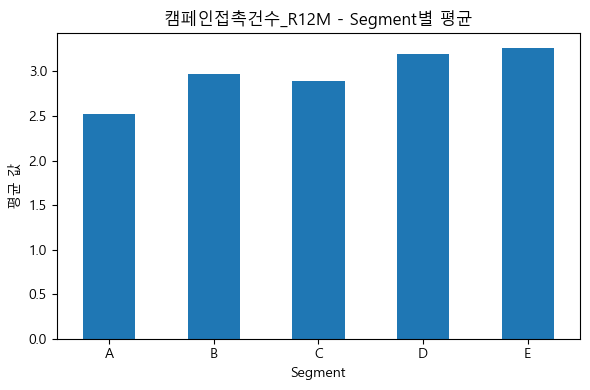

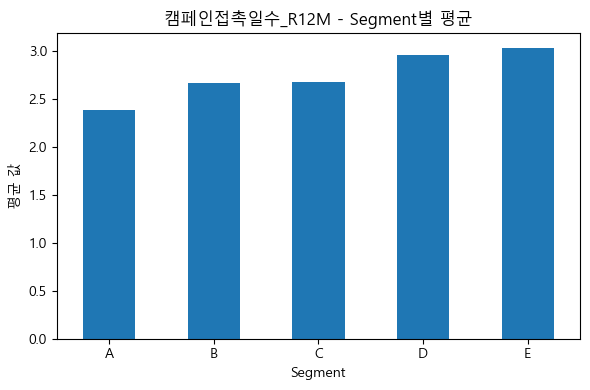

In [40]:
# Segment별 평균값 계산
segment_grouped = merged_df.groupby('Segment')[campaign_cols].mean()

# 컬럼별 Bar Plot 시각화
for col in campaign_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균')
    plt.xlabel('Segment')
    plt.ylabel('평균 값')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

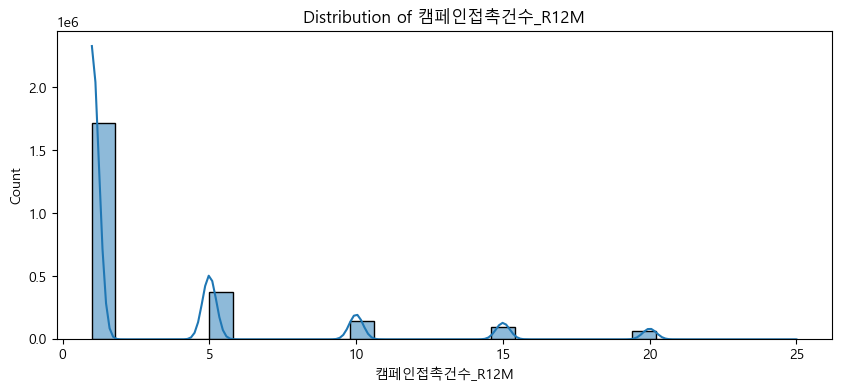

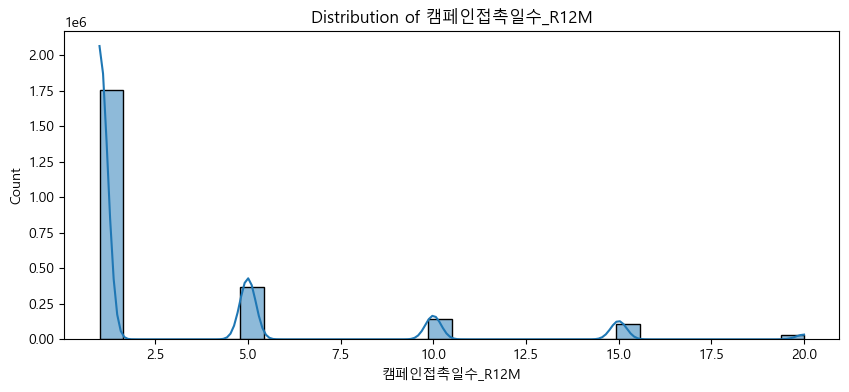

In [41]:
for col in campaign_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=merged_df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

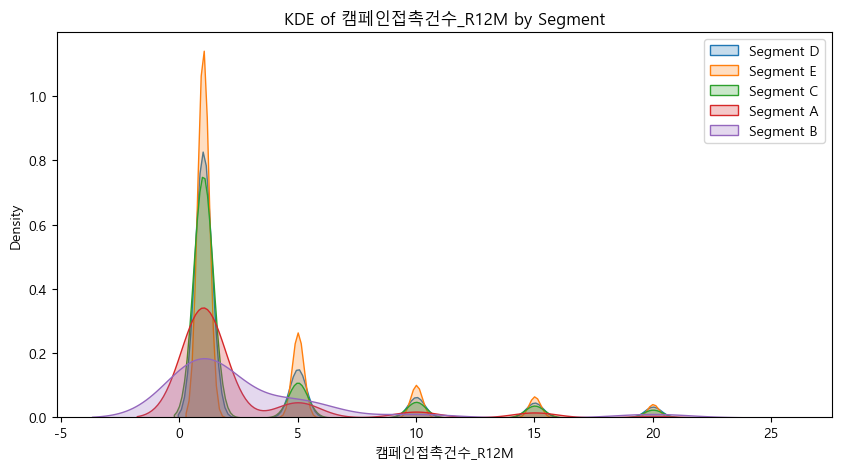

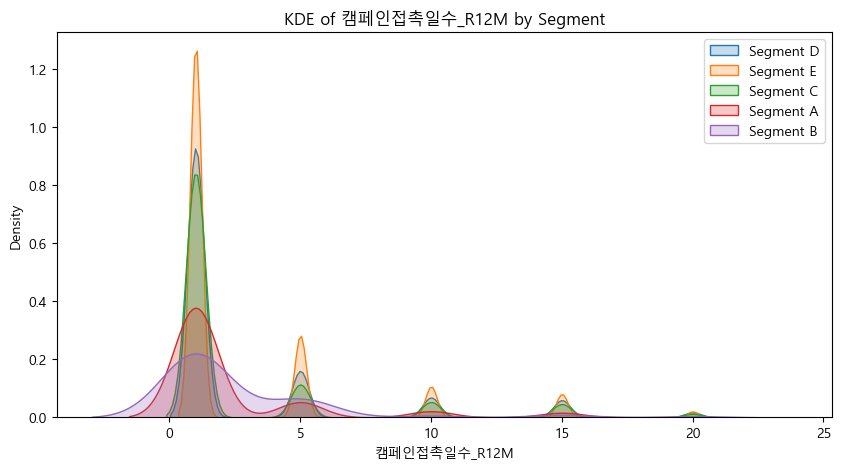

In [42]:
# tm_cols 리스트에 해당하는 컬럼들에 대해 반복
for col in campaign_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg],
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.show()

## 2차 검증

In [44]:
from scipy.stats import f_oneway

cde_df = merged_df[merged_df['Segment'].isin(['C', 'D', 'E'])]
groups = [group['컨택건수_이용유도_EM_R6M'].dropna() for name, group in cde_df.groupby('Segment')]
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")

F-statistic: 26200.018, p-value: 0.00000


In [46]:
cols = [
    '컨택건수_이용유도_EM_R6M',
    '컨택건수_이용유도_EM_B0M',
    '컨택건수_이용유도_청구서_R6M',
    '컨택건수_이용유도_청구서_B0M',
    '컨택건수_이용유도_LMS_R6M'
]

segment_targets = ['C', 'D', 'E']

# 결과 저장
cv_results = {}

for col in cols:
    cv_results[col] = {}
    for seg in segment_targets:
        seg_data = merged_df[merged_df['Segment'] == seg][col].dropna()
        mean = seg_data.mean()
        std = seg_data.std()
        cv = std / mean if mean != 0 else float('inf')
        cv_results[col][seg] = round(cv, 3)

# 결과 보기
import pandas as pd
cv_df = pd.DataFrame(cv_results).T
cv_df.columns = ['CV_C', 'CV_D', 'CV_E']
cv_df['CV_Diff_D_vs_CE'] = cv_df['CV_D'] - ((cv_df['CV_C'] + cv_df['CV_E']) / 2)
cv_df


,CV_C,CV_D,CV_E,CV_Diff_D_vs_CE
컨택건수_이용유도_EM_R6M,1.289,1.275,1.660,-0.1995
컨택건수_이용유도_EM_B0M,1.722,1.694,2.413,-0.3735
컨택건수_이용유도_청구서_R6M,1.511,1.299,1.200,-0.0565
컨택건수_이용유도_청구서_B0M,1.563,1.514,1.619,-0.0770
컨택건수_이용유도_LMS_R6M,1.255,1.259,1.217,0.0230


In [94]:
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


# Segment C/D/E만 사용
# cde_df = merged_df[merged_df['Segment'].isin(['C', 'D', 'E'])].copy()
cde_df = merged_df[merged_df['Segment'].isin(['A','B','C', 'D', 'E'])].copy()

# 수치형 컬럼 자동 추출
numeric_cols = cde_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'ID']  # ID 등 제외

# 결과 저장
results = []

for col in numeric_cols:
    try:
        # binning (5등분, quantile 기반)
        discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
        binned = discretizer.fit_transform(cde_df[[col]])
        cde_df['binned'] = binned

        # 교차표 생성
        contingency = pd.crosstab(cde_df['binned'], cde_df['Segment'])

        # 카이제곱 검정
        chi2, p, dof, expected = chi2_contingency(contingency)

        results.append({
            'Feature': col,
            'Chi2 Stat': chi2,
            'p-value': round(p, 10),
            'Significant': '✅ Yes' if p < 0.05 else '❌ No'
        })
    except:
        continue  # NaN 또는 에러나는 컬럼은 건너뜀

# 상위 10개 정렬 및 출력
result_df = pd.DataFrame(results)
top10 = result_df.sort_values(by='Chi2 Stat', ascending=False).head(10)
top10[['Feature', 'Chi2 Stat', 'p-value', 'Significant']]


,Feature,Chi2 Stat,p-value,Significant
28,컨택건수_이용유도_EM_R6M,59438.122927,0.0,✅ Yes
10,컨택건수_이용유도_EM_B0M,51455.096151,0.0,✅ Yes
18,컨택건수_이용유도_TM_R6M,45575.100056,0.0,✅ Yes
32,컨택건수_이용유도_인터넷_R6M,14532.762699,0.0,✅ Yes
22,컨택건수_보험_TM_R6M,6014.756075,0.0,✅ Yes
26,컨택건수_이용유도_LMS_R6M,5520.684992,0.0,✅ Yes
8,컨택건수_이용유도_LMS_B0M,5162.380540,0.0,✅ Yes
13,컨택건수_이용유도_청구서_B0M,4097.536113,0.0,✅ Yes
36,캠페인접촉일수_R12M,3685.465406,0.0,✅ Yes
35,캠페인접촉건수_R12M,3560.824317,0.0,✅ Yes


In [98]:
from scipy.stats import f_oneway

groups = [group[col].dropna() for name, group in cde_df.groupby('Segment')]
stat, p_val = f_oneway(*groups)


# Segment C/D/E만 사용
cde_df = merged_df[merged_df['Segment'].isin(['C', 'D', 'E'])].copy()
# cde_df = merged_df[merged_df['Segment'].isin(['A','B','C', 'D', 'E'])].copy()


# 수치형 컬럼 자동 추출
numeric_cols = cde_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'ID']  # ID 등 제외

# 결과 저장
results = []

for col in numeric_cols:
    try:
        # binning (5등분, quantile 기반)
        discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
        binned = discretizer.fit_transform(cde_df[[col]])
        cde_df['binned'] = binned

        # 교차표 생성
        contingency = pd.crosstab(cde_df['binned'], cde_df['Segment'])

        # 카이제곱 검정
        chi2, p, dof, expected = chi2_contingency(contingency)

        results.append({
            'Feature': col,
            'Chi2 Stat': chi2,
            'p-value': round(p, 10),
            'Significant': '✅ Yes' if p < 0.05 else '❌ No'
        })
    except:
        continue  # NaN 또는 에러나는 컬럼은 건너뜀

# 상위 10개 정렬 및 출력
result_df = pd.DataFrame(results)
top10 = result_df.sort_values(by='Chi2 Stat', ascending=False).head(10)
top10[['Feature', 'Chi2 Stat', 'p-value', 'Significant']]


,Feature,Chi2 Stat,p-value,Significant
28,컨택건수_이용유도_EM_R6M,59259.558467,0.0,✅ Yes
10,컨택건수_이용유도_EM_B0M,51245.123117,0.0,✅ Yes
18,컨택건수_이용유도_TM_R6M,45205.089102,0.0,✅ Yes
32,컨택건수_이용유도_인터넷_R6M,14454.378623,0.0,✅ Yes
22,컨택건수_보험_TM_R6M,6001.409102,0.0,✅ Yes
26,컨택건수_이용유도_LMS_R6M,5479.436007,0.0,✅ Yes
8,컨택건수_이용유도_LMS_B0M,5024.216726,0.0,✅ Yes
13,컨택건수_이용유도_청구서_B0M,4063.172292,0.0,✅ Yes
36,캠페인접촉일수_R12M,3657.751496,0.0,✅ Yes
35,캠페인접촉건수_R12M,3526.025372,0.0,✅ Yes
